# PCA — Principal Component Analysis

## Topic 1: Theory

---

## 1. What is Dimensionality Reduction?

First, understand the problem PCA is trying to solve.

Suppose we have a dataset containing information about students:

| Student | Hours Studied | Attendance | Assignments | Sleep |
| ------- | ------------: | ---------: | ----------: | ----: |
| A       |             5 |         90 |           8 |     7 |
| B       |             6 |         92 |           9 |     7 |
| C       |             2 |         60 |           4 |     5 |

Here, every student is represented using **4 features**.

So each student exists in a 4-dimensional feature space.

If we had 100 features, each data point would have 100 dimensions.

Dimensionality reduction means:

> **Represent the same data using fewer dimensions while preserving as much useful information as possible.**

For example:

$$
100\text{ features}
\rightarrow
10\text{ dimensions}
$$

---

# 2. Why Do We Need Dimensionality Reduction?

As the number of features increases, several problems can occur.

### Problem 1: Too many features

A dataset might contain hundreds or thousands of features.

Working with all of them can increase computational cost.

### Problem 2: Redundant information

Two or more features may contain very similar information.

For example:

* height in cm
* height in inches

Both describe almost the same thing.

Keeping both may not provide much additional information.

### Problem 3: Visualization

Humans can easily visualize:

$$
2\text{ dimensions}
$$

or:

$$
3\text{ dimensions}
$$

But visualizing:

$$
50\text{ dimensions}
$$

is not directly possible.

Dimensionality reduction can transform:

$$
50\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

so that we can visualize the data.

---

# 3. What is PCA?

**PCA = Principal Component Analysis**

PCA is one of the most commonly used dimensionality-reduction techniques.

The central idea is:

> **PCA finds new directions in the data that capture the largest amount of variation.**

These new directions are called **principal components**.

Let's understand that statement carefully.

---

# 4. What Does "Variation" Mean?

Imagine we have the following values:

$$
5,\ 5,\ 5,\ 5,\ 5
$$

All values are almost identical.

There is very little variation.

Now consider:

$$
1,\ 3,\ 5,\ 7,\ 9
$$

These values are much more spread out.

Therefore, they have greater variation.

In statistics, we measure this spread using **variance**.

So, informally:

$$
\text{More spread}
\rightarrow
\text{Higher variance}
$$

and:

$$
\text{Less spread}
\rightarrow
\text{Lower variance}
$$

PCA uses this idea to find important directions in the data.

---

# 5. Imagine Data as Points

Suppose we have two features:

* Height
* Weight

Each person becomes a point.

For example:

$$
X=
\begin{bmatrix}
\text{Height}&\text{Weight}
\end{bmatrix}
$$

Imagine the points look approximately like this:

```text
Weight
  |
  |                         •
  |                    •
  |                •
  |            •
  |        •
  |    •
  | •
  +-------------------------------- Height
```

Notice that the points are not randomly distributed.

They mostly follow a diagonal direction.

So although the data has **two features**, most of its variation occurs along this diagonal.

This is the key observation behind PCA.

---

# 6. PCA Finds a New Direction

PCA asks:

> **What direction through the data captures the largest variation?**

In our example, PCA might find:

```text
Weight
  |
  |                       •
  |                  •
  |              •
  |          •
  |      •
  |   •
  | •
  +------------------------------ Height
             ↗
            PC1
```

That diagonal direction is called the **first principal component**.

We write:

$$
PC_1
$$

PC1 is the direction containing the maximum variance.

So:

$$
PC_1
\rightarrow
\text{maximum variance}
$$

---

# 7. Why Is This Useful?

Originally, we represented every person using:

$$
\text{Height},\text{Weight}
$$

That's 2 dimensions.

But if most of the useful variation is along PC1, perhaps we don't need both original dimensions.

We can represent each point using its position along PC1.

Therefore:

$$
2\text{ dimensions}
\rightarrow
1\text{ dimension}
$$

while trying to preserve most of the information.

This is dimensionality reduction.

---

# 8. What is a Principal Component?

A principal component is a **new feature/direction created from the original features**.

Suppose our original features are:

$$
X_1=\text{Height}
$$

$$
X_2=\text{Weight}
$$

PCA can create a component such as:

$$
PC_1=0.7X_1+0.7X_2
$$

This means PC1 is a combination of the original features.

It is **not** simply Height.

It is **not** simply Weight.

It is a new feature constructed from them.

---

# 9. PCA Does Feature Selection?

**No.**

This distinction is very important.

### Feature selection

Feature selection chooses some of the original features.

For example:

$$
X_1,X_2,X_3,X_4
\rightarrow
X_1,X_3
$$

We simply removed features.

### PCA

PCA creates completely new features:

$$
X_1,X_2,X_3,X_4
\rightarrow
PC_1,PC_2
$$

The principal components are combinations of the original features.

So PCA is better thought of as:

> **Feature transformation, not feature selection.**

---

# 10. What Happens to the Data?

Suppose our original dataset has:

* 100 observations
* 10 features

Then its shape is:

$$
X\in\mathbb{R}^{100\times10}
$$

If we use PCA and keep only 3 components:

$$
X
\rightarrow
X_{\text{PCA}}
$$

with:

$$
X_{\text{PCA}}\in\mathbb{R}^{100\times3}
$$

Notice:

**100 observations remain 100 observations.**

Only the number of dimensions changes:

$$
100\times10
\rightarrow
100\times3
$$

---

# 11. The Main Idea of PCA

Let's summarize the intuition before introducing any mathematics.

Suppose data looks like:

```text
             •
          •
       •
    •
 •
```

PCA searches for the direction where the points are most spread out.

That becomes:

$$
PC_1
$$

Then it searches for another important direction perpendicular to PC1.

That becomes:

$$
PC_2
$$

Then another:

$$
PC_3
$$

and so on.

The components are ordered by how much variance they capture:

$$
PC_1
\rightarrow
\text{largest variance}
$$

$$
PC_2
\rightarrow
\text{second-largest variance}
$$

$$
PC_3
\rightarrow
\text{third-largest variance}
$$

Therefore, if PC1 and PC2 contain most of the variation, we can discard the later components.

---

# 12. Simple Example

Suppose a dataset has three features:

$$
X_1=\text{Height}
$$

$$
X_2=\text{Weight}
$$

$$
X_3=\text{Age}
$$

So:

$$
3\text{ dimensions}
$$

After PCA, suppose we obtain:

$$
PC_1
$$

$$
PC_2
$$

$$
PC_3
$$

and discover that:

* PC1 captures 80% of the variance
* PC2 captures 15%
* PC3 captures 5%

Then:

$$
80\%+15\%=95\%
$$

So keeping only PC1 and PC2 retains **95% of the variance**.

We can therefore reduce:

$$
3\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

while retaining approximately 95% of the variance.

We will later learn exactly how PCA calculates these percentages under **Explained Variance**.

---

# 13. The Complete PCA Idea

At a very high level:

$$
\text{Original Data}
\rightarrow
\text{Find directions of maximum variance}
\rightarrow
\text{Create principal components}
\rightarrow
\text{Rank components}
\rightarrow
\text{Keep important components}
\rightarrow
\text{Reduced Data}
$$

The mathematical machinery that allows PCA to find these directions involves concepts such as:

* mean-centering
* covariance
* eigenvalues
* eigenvectors

We will learn those **one by one later**, rather than assuming you already understand them.

---

# 14. One Sentence to Remember

If you remember only one thing from Topic 1:

> **PCA transforms the original features into new principal components, where the first components capture the largest variation in the data, allowing us to reduce the number of dimensions while preserving important information.**

### Mental picture

$$
\boxed{
\text{Many Features}
\rightarrow
\text{New Directions}
\rightarrow
\text{Most Important Directions}
}
$$


# Topic 2: Variance & Information

## 1. What is Variance?

### What it means

Variance tells us **how much the data points are spread out from their mean**.

Consider two datasets.

### Dataset A

$$
2,\ 2,\ 2,\ 2,\ 2
$$

All values are the same, so there is no spread.

$$
\text{Variance}=0
$$

### Dataset B

$$
1,\ 2,\ 5,\ 8,\ 9
$$

The values are spread out much more.

$$
\text{Variance}>0
$$

So:

$$
\text{More spread}
\rightarrow
\text{Higher variance}
$$

$$
\text{Less spread}
\rightarrow
\text{Lower variance}
$$

---

# 2. Why Does PCA Care About Variance?

PCA is based on the idea that **directions with greater variation contain more information about the structure of the data**.

Imagine this:

```text
        •
      •
    •
  •
•
```

There is a lot of variation along the diagonal direction.

But there is very little variation perpendicular to it.

Therefore, PCA wants to preserve the diagonal direction.

Conceptually:

$$
\text{High variance}
\rightarrow
\text{Important direction}
$$

$$
\text{Low variance}
\rightarrow
\text{Less important direction}
$$

This is why PCA searches for the direction of **maximum variance**.

---

# 3. Mean

Before calculating variance, we need the **mean**.

### What it means

The mean is the average value of the data.

### Formula

For \(n\) observations:

$$
\bar{x}
=
\frac{x_1+x_2+\cdots+x_n}{n}
$$

### Meaning of each term

* \(x_1,x_2,\ldots,x_n\) = observations
* \(n\) = number of observations
* \(\bar{x}\) = mean

---

# 4. Small Example

Take:

$$
2,\ 4,\ 6
$$

The mean is:

$$
\bar{x}
=
\frac{2+4+6}{3}
$$

$$
\bar{x}
=
\frac{12}{3}
=
4
$$

So:

$$
\boxed{\bar{x}=4}
$$

The mean is the center around which we measure the spread.

---

# 5. Deviation from the Mean

Now we calculate how far each observation is from the mean.

Our data is:

$$
2,\ 4,\ 6
$$

Mean:

$$
\bar{x}=4
$$

Calculate each deviation:

For \(2\):

$$
2-4=-2
$$

For \(4\):

$$
4-4=0
$$

For \(6\):

$$
6-4=2
$$

Therefore:

$$
\text{Deviations}
=
-2,\ 0,\ 2
$$

The problem is that if we simply add them:

$$
-2+0+2=0
$$

The positive and negative deviations cancel each other.

So we cannot use the simple sum to measure spread.

---

# 6. Squaring the Deviations

We square every deviation.

$$
(-2)^2=4
$$

$$
0^2=0
$$

$$
2^2=4
$$

Therefore:

$$
4,\ 0,\ 4
$$

Now all values are positive.

Their sum is:

$$
4+0+4=8
$$

---

# 7. Variance Formula

For a population, variance is:

$$
\sigma^2
=
\frac{1}{n}
\sum_{i=1}^{n}(x_i-\mu)^2
$$

For a sample, we commonly use:

$$
s^2
=
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

For understanding PCA, the important structure is:

$$
\text{Variance}
=
\text{average squared distance from the mean}
$$

---

# 8. Complete Calculation

Using:

$$
2,\ 4,\ 6
$$

Mean:

$$
\bar{x}=4
$$

Deviations:

$$
-2,\ 0,\ 2
$$

Squared deviations:

$$
4,\ 0,\ 4
$$

Using population variance:

$$
\sigma^2
=
\frac{4+0+4}{3}
$$

$$
\sigma^2
=
\frac{8}{3}
$$

$$
\boxed{\sigma^2\approx2.67}
$$

So the data has a variance of approximately \(2.67\).

---

# 9. How Variance Represents Information

Consider two possible directions through a dataset.

### Direction A

Data projected onto this direction:

$$
1,\ 2,\ 3,\ 4,\ 5
$$

There is significant spread.

### Direction B

Data projected onto this direction:

$$
3.0,\ 3.1,\ 3.0,\ 3.1,\ 3.0
$$

There is very little spread.

PCA considers Direction A more informative because the data varies much more along it.

Therefore:

$$
\text{Direction A}
\rightarrow
\text{High variance}
\rightarrow
\text{More information}
$$

$$
\text{Direction B}
\rightarrow
\text{Low variance}
\rightarrow
\text{Less information}
$$

---

# 10. Variance in Multiple Dimensions

Now suppose each observation has two features:

$$
X_1=\text{Height}
$$

$$
X_2=\text{Weight}
$$

The dataset can be visualized as points in a 2D space.

PCA doesn't only ask:

> "What is the variance of Height?"

or:

> "What is the variance of Weight?"

It asks a more interesting question:

> **What is the variance if we look at the data along a particular direction?**

For example:

```text
             •
          •
       •
    •
 •
```

A diagonal direction might have very high variance.

A perpendicular direction might have very low variance.

So PCA searches across possible directions:

$$
\text{Direction 1}
\rightarrow
\text{calculate variance}
$$

$$
\text{Direction 2}
\rightarrow
\text{calculate variance}
$$

$$
\text{Direction 3}
\rightarrow
\text{calculate variance}
$$

and finds the direction having the maximum variance.

That direction becomes **PC1**.

---

# 11. Important PCA Insight

This is the key connection:

### Variance tells us:

> How much the data changes along a direction.

### PCA assumes:

> Directions where the data changes more are more useful for representing the data.

Therefore:

$$
\boxed{
\text{Maximum Variance}
\rightarrow
\text{Principal Component 1}
}
$$

Then PCA finds the next best direction:

$$
\boxed{
\text{Next Maximum Variance}
\rightarrow
\text{Principal Component 2}
}
$$

and continues similarly.

---

# 12. Why Can Low-Variance Components Be Removed?

Suppose PCA produces three components:

| Component | Variance |
| --------- | -------: |
| PC1       |       80 |
| PC2       |       15 |
| PC3       |        5 |

Total variance:

$$
80+15+5=100
$$

PC1 contains:

$$
\frac{80}{100}\times100=80\%
$$

PC2 contains:

$$
\frac{15}{100}\times100=15\%
$$

PC3 contains:

$$
\frac{5}{100}\times100=5\%
$$

Together:

$$
PC_1+PC_2=95\%
$$

So we can reduce:

$$
3\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

while retaining approximately 95% of the variance.

The 5% represented by PC3 is discarded.

---

# 13. Important Limitation of the "Variance = Information" Idea

PCA's assumption is:

$$
\text{Higher variance}
\approx
\text{More useful information}
$$

But this is **not always true**.

A feature can have high variance because of noise or outliers.

For example:

$$
10,\ 11,\ 10,\ 12,\ 1000
$$

The value \(1000\) creates enormous variance, but it may not represent useful information.

So PCA does not literally know what information is useful.

It uses **variance as a mathematical criterion**.

This distinction is important:

> PCA preserves high variance, not necessarily the information that humans consider meaningful.

---

# 14. Connection to PCA

We can now understand the first major mathematical goal of PCA:

$$
\text{Data}
\rightarrow
\text{Look at different directions}
\rightarrow
\text{Measure variance along each direction}
\rightarrow
\text{Choose maximum-variance direction}
$$

The maximum-variance direction is:

$$
PC_1
$$

Then:

$$
PC_1
\rightarrow
\text{largest variance}
$$

$$
PC_2
\rightarrow
\text{next largest variance}
$$

$$
PC_3
\rightarrow
\text{next largest variance}
$$

This ordering is what eventually allows us to decide how many components to keep.


# Example: Height and Weight

Suppose we have 3 people:

| Person | Height $X_1$ | Weight $X_2$ |
| ------ | -----------: | -----------: |
| A      |            1 |            1 |
| B      |            2 |            2 |
| C      |            3 |            3 |

So our data is:

$$
X=
\begin{bmatrix}
1&1\\
2&2\\
3&3
\end{bmatrix}
$$

Each row is one person, and each column is one feature.

---

## Step 1: Look at the Data

Plotting these points:

```text
Weight
  3 |             ● C
  2 |       ● B
  1 | ● A
    +------------------
      1   2   3   Height
```

Notice that the points lie along a diagonal.

So the data is changing mainly in this direction:

```text
      ●
    ↗
  ●
↗
●
```

PCA wants to find this direction.

---

# Step 2: Consider a Direction

Suppose PCA considers this direction:

$$
w=
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

Why this direction?

Because it points diagonally upward.

Its length is:

$$
\sqrt{
\left(\frac{1}{\sqrt{2}}\right)^2+
\left(\frac{1}{\sqrt{2}}\right)^2
}
$$

$$
=
\sqrt{
\frac{1}{2}+\frac{1}{2}
}
$$

$$
=1
$$

So it is a unit direction.

---

# Step 3: Project the Data onto This Direction

The projection of a point onto the direction $w$ is:

$$
PC_1=w^Tx
$$

Let's take Person A.

Their data point is:

$$
x_A=
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

And:

$$
w^T=
\begin{bmatrix}
\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

Therefore:

$$
PC_{1,A}
=
\begin{bmatrix}
\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

$$
=
\frac{1}{\sqrt{2}}+
\frac{1}{\sqrt{2}}
$$

$$
=\sqrt{2}
$$

So Person A gets a new coordinate:

$$
PC_{1,A}=\sqrt{2}
$$

---

### Person B

$$
x_B=
\begin{bmatrix}
2\\
2
\end{bmatrix}
$$

Therefore:

$$
PC_{1,B}
=
\begin{bmatrix}
\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
2\\
2
\end{bmatrix}
$$

$$
=
\frac{2}{\sqrt{2}}+
\frac{2}{\sqrt{2}}
$$

$$
=2\sqrt{2}
$$

---

### Person C

$$
x_C=
\begin{bmatrix}
3\\
3
\end{bmatrix}
$$

Therefore:

$$
PC_{1,C}
=
\begin{bmatrix}
\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
3\\
3
\end{bmatrix}
$$

$$
=
\frac{3}{\sqrt{2}}+
\frac{3}{\sqrt{2}}
$$

$$
=3\sqrt{2}
$$

---

# Step 4: What Did We Achieve?

Originally, every person needed **two numbers**:

| Person | Height | Weight |
| ------ | -----: | -----: |
| A      |      1 |      1 |
| B      |      2 |      2 |
| C      |      3 |      3 |

After projecting onto PC1, we need only **one number**:

| Person |         PC1 |
| ------ | ----------: |
| A      |  $\sqrt{2}$ |
| B      | $2\sqrt{2}$ |
| C      | $3\sqrt{2}$ |

So:

$$
2\text{ dimensions}\rightarrow1\text{ dimension}
$$

But we still preserve the main pattern of the data.

---

# Step 5: Why Is This PC1?

Because the direction:

$$
w=
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

is pointing exactly along the direction in which our data changes.

The points move:

$$
(1,1)\rightarrow(2,2)\rightarrow(3,3)
$$

So almost all the variation is along this diagonal.

Therefore:

$$
\boxed{
PC_1=
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
}
$$

This vector represents the **direction** of the first principal component.

---

# Step 6: What Is PC2?

PC2 must be perpendicular to PC1.

So we can choose:

$$
PC_2=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

Now project Person A onto PC2:

$$
\begin{bmatrix}
-\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

$$
=
-\frac{1}{\sqrt{2}}
+
\frac{1}{\sqrt{2}}
$$

$$
=0
$$

For Person B:

$$
\begin{bmatrix}
-\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
2\\
2
\end{bmatrix}
=0
$$

For Person C:

$$
\begin{bmatrix}
-\frac{1}{\sqrt{2}}&
\frac{1}{\sqrt{2}}
\end{bmatrix}
\begin{bmatrix}
3\\
3
\end{bmatrix}
=0
$$

Therefore:

$$
PC_2=
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}
$$

There is **no variation** in the PC2 direction.

---

# The Big Picture

Original data:

$$
X=
\begin{bmatrix}
1&1\\
2&2\\
3&3
\end{bmatrix}
$$

PCA discovers:

$$
PC_1=
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

and:

$$
PC_2=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

The data has:

$$
\text{large variation along }PC_1
$$

and:

$$
\text{zero variation along }PC_2
$$

Therefore we can keep only PC1:

$$
\boxed{
2\text{ original features}
\rightarrow
1\text{ principal component}
}
$$

### The Most Important Thing to Understand

The principal component is **not** the values:

$$
\sqrt{2},\quad2\sqrt{2},\quad3\sqrt{2}
$$

The **direction** is:

$$
\boxed{
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\
\frac{1}{\sqrt{2}}
\end{bmatrix}
}
$$

The values:

$$
\sqrt{2},\quad2\sqrt{2},\quad3\sqrt{2}
$$

are the **coordinates of the data after projecting it onto that principal direction**.


# Topic 4: Mean-Centering

## 1. What is Mean-Centering?

### What it means

Mean-centering means **subtracting the mean of each feature from every value in that feature**.

The goal is to move the center of the data to zero.

For example, suppose one feature contains:

$$
2,\ 4,\ 6
$$

Its mean is:

$$
\bar{x}
=
\frac{2+4+6}{3}
=
4
$$

Now subtract the mean from every value:

$$
2-4=-2
$$

$$
4-4=0
$$

$$
6-4=2
$$

The centered data becomes:

$$
-2,\ 0,\ 2
$$

Notice that the new mean is zero:

$$
\frac{-2+0+2}{3}=0
$$

---

# 2. Why Does PCA Need Mean-Centering?

PCA is interested in the **variation around the center of the data**.

Suppose our data is located far away from the origin:

```text
Weight
  |
  |                  •
  |              •
  |          •
  |      •
  |  •
  +-------------------------- Height
```

The important pattern is the direction in which the points spread.

But the coordinate system currently has its origin somewhere else.

Mean-centering moves the data so that its center is at the origin:

```text
Weight
  |
  |            •
  |        •
  |    •
  | •
  +-------------------------- Height
             (0,0)
```

This allows PCA to analyze the variation around the actual center of the data.

So:

$$
\text{Original Data}
\rightarrow
\text{Subtract Mean}
\rightarrow
\text{Centered Data}
$$

---

# 3. Mean-Centering One Feature

Suppose we have:

$$
X=
\begin{bmatrix}
2\\
4\\
6
\end{bmatrix}
$$

The mean is:

$$
\bar{x}
=
\frac{2+4+6}{3}
$$

$$
\bar{x}=4
$$

Now subtract \(4\) from every value:

$$
X_{\text{centered}}
=
\begin{bmatrix}
2-4\\
4-4\\
6-4
\end{bmatrix}
$$

Therefore:

$$
X_{\text{centered}}
=
\begin{bmatrix}
-2\\
0\\
2
\end{bmatrix}
$$

The mean of the centered data is:

$$
\frac{-2+0+2}{3}=0
$$

---

# 4. Mean-Centering Multiple Features

In PCA, we normally have multiple features.

Suppose we have:

| Student | Height | Weight |
| ------- | -----: | -----: |
| A       |      1 |     10 |
| B       |      2 |     20 |
| C       |      3 |     30 |

Represent the data as:

$$
X=
\begin{bmatrix}
1&10\\
2&20\\
3&30
\end{bmatrix}
$$

We center **each feature separately**.

---

## Step 1: Calculate the mean of Height

Height values are:

$$
1,\ 2,\ 3
$$

Mean:

$$
\bar{x}_1
=
\frac{1+2+3}{3}
=
2
$$

---

## Step 2: Calculate the mean of Weight

Weight values are:

$$
10,\ 20,\ 30
$$

Mean:

$$
\bar{x}_2
=
\frac{10+20+30}{3}
=
20
$$

So the feature means are:

$$
\mu=
\begin{bmatrix}
2\\
20
\end{bmatrix}
$$

---

# 5. Subtract the Means

Original data:

$$
X=
\begin{bmatrix}
1&10\\
2&20\\
3&30
\end{bmatrix}
$$

For the first row:

$$
\begin{bmatrix}
1&10
\end{bmatrix}
-
\begin{bmatrix}
2&20
\end{bmatrix}
=
\begin{bmatrix}
-1&-10
\end{bmatrix}
$$

For the second row:

$$
\begin{bmatrix}
2&20
\end{bmatrix}
-
\begin{bmatrix}
2&20
\end{bmatrix}
=
\begin{bmatrix}
0&0
\end{bmatrix}
$$

For the third row:

$$
\begin{bmatrix}
3&30
\end{bmatrix}
-
\begin{bmatrix}
2&20
\end{bmatrix}
=
\begin{bmatrix}
1&10
\end{bmatrix}
$$

Therefore, the centered dataset is:

$$
X_c=
\begin{bmatrix}
-1&-10\\
0&0\\
1&10
\end{bmatrix}
$$

---

# 6. What Changed?

Original data:

$$
X=
\begin{bmatrix}
1&10\\
2&20\\
3&30
\end{bmatrix}
$$

Centered data:

$$
X_c=
\begin{bmatrix}
-1&-10\\
0&0\\
1&10
\end{bmatrix}
$$

The **relationships between the data points did not change**.

The entire dataset was simply shifted so that its center became zero.

For Height:

$$
\frac{-1+0+1}{3}=0
$$

For Weight:

$$
\frac{-10+0+10}{3}=0
$$

Therefore, every feature now has mean zero.

---

# 7. General Formula

For an individual value \(x_{ij}\), the centered value is:

$$
x_{ij}^{(c)}
=
x_{ij}-\bar{x}_j
$$

### Meaning of each term

* \(x_{ij}\) = value of feature \(j\) for observation \(i\)
* \(\bar{x}_j\) = mean of feature \(j\)
* \(x_{ij}^{(c)}\) = centered value

So the process is simply:

$$
\boxed{
\text{Centered Value}
=
\text{Original Value}
-
\text{Feature Mean}
}
$$

---

# 8. Why Do We Center Each Feature Separately?

Consider:

$$
X=
\begin{bmatrix}
1&10\\
2&20\\
3&30
\end{bmatrix}
$$

The means are different:

$$
\mu=
\begin{bmatrix}
2\\
20
\end{bmatrix}
$$

We cannot subtract one common mean from the entire dataset.

Instead:

* subtract \(2\) from the Height column
* subtract \(20\) from the Weight column

This ensures every feature is centered around zero.

---

# 9. Mean-Centering and PCA

Now connect this to what we learned previously.

PCA searches for directions with maximum variance.

Variance measures how data spreads **around its mean**.

Therefore, PCA first needs to know where the center of each feature is.

Mean-centering gives us that:

$$
\text{Original Data}
\rightarrow
\text{Calculate Feature Means}
\rightarrow
\text{Subtract Feature Means}
\rightarrow
\text{Centered Data}
$$

Then PCA can analyze the variation of the centered data.

---

# 10. Important Distinction: Centering vs Scaling

Mean-centering and scaling are **not the same thing**.

### Mean-centering

Moves the mean to zero.

$$
x
\rightarrow
x-\bar{x}
$$

### Scaling

Changes the scale or spread of the feature.

For example, standardization commonly uses:

$$
z=
\frac{x-\bar{x}}{s}
$$

where \(s\) is the standard deviation.

For now, the important idea is:

> **Centering changes the location of the data, while scaling changes its scale.**

PCA requires understanding centering before we move to the covariance matrix.

---

# 11. Complete Example

Original dataset:

$$
X=
\begin{bmatrix}
2&4\\
4&8\\
6&12
\end{bmatrix}
$$

### Feature means

First feature:

$$
\bar{x}_1
=
\frac{2+4+6}{3}
=
4
$$

Second feature:

$$
\bar{x}_2
=
\frac{4+8+12}{3}
=
8
$$

Therefore:

$$
\mu=
\begin{bmatrix}
4\\
8
\end{bmatrix}
$$

### Center the data

$$
X_c=
\begin{bmatrix}
2-4&4-8\\
4-4&8-8\\
6-4&12-8
\end{bmatrix}
$$

$$
X_c=
\begin{bmatrix}
-2&-4\\
0&0\\
2&4
\end{bmatrix}
$$

Now calculate the mean of each centered feature:

First feature:

$$
\frac{-2+0+2}{3}=0
$$

Second feature:

$$
\frac{-4+0+4}{3}=0
$$

So the centered dataset has zero mean for every feature.

---

# 12. Where Mean-Centering Fits in PCA

The PCA process we have learned so far is:

$$
\text{Original Data}
\rightarrow
\text{Mean-Centering}
\rightarrow
\text{Find Variance Directions}
\rightarrow
\text{Principal Components}
$$

Mean-centering is important because PCA wants to study **how the data varies around its center**, rather than where the entire dataset happens to be located.


# Topic 5: Covariance Matrix

## 1. What is Covariance?

### What it means

Variance tells us how **one feature changes by itself**.

Covariance tells us how **two features change together**.

For example, consider:

* Height
* Weight

If height increases and weight also tends to increase, they have **positive covariance**.

If one increases while the other tends to decrease, they have **negative covariance**.

If there is no clear relationship between their changes, covariance is close to zero.

---

## 2. Why Does PCA Need Covariance?

PCA needs to understand the **relationships between features**.

Suppose we have:

$$
X_1=\text{Height}
$$

$$
X_2=\text{Weight}
$$

If Height and Weight increase together, PCA should know that these features contain related information.

Covariance captures this relationship.

So:

$$
\text{Data}
\rightarrow
\text{Feature Relationships}
\rightarrow
\text{Covariance Matrix}
$$

PCA then uses this matrix to find the directions of maximum variance.

---

# 3. Understanding Covariance with a Small Example

Consider:

| Person | Height | Weight |
| ------ | -----: | -----: |
| A      |      1 |      2 |
| B      |      2 |      4 |
| C      |      3 |      6 |

Represent the data as:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

As Height increases:

$$
1\rightarrow2\rightarrow3
$$

Weight also increases:

$$
2\rightarrow4\rightarrow6
$$

So the two features move together.

We expect their covariance to be **positive**.

---

# 4. Mean-Center the Data First

We learned that PCA works with centered data.

Mean of Height:

$$
\bar{x}_1
=
\frac{1+2+3}{3}
=
2
$$

Mean of Weight:

$$
\bar{x}_2
=
\frac{2+4+6}{3}
=
4
$$

Therefore:

$$
\mu=
\begin{bmatrix}
2\\
4
\end{bmatrix}
$$

Now subtract the means.

$$
X_c=
\begin{bmatrix}
1-2&2-4\\
2-2&4-4\\
3-2&6-4
\end{bmatrix}
$$

Therefore:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

---

# 5. Covariance Between Two Features

### What it means

Covariance measures whether two features move together.

For two features \(X\) and \(Y\), population covariance is:

$$
\operatorname{Cov}(X,Y)
=
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
$$

For a sample, we commonly use:

$$
\operatorname{Cov}(X,Y)
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
$$

The important part is:

$$
(x_i-\bar{x})(y_i-\bar{y})
$$

It tells us whether the two features are deviating from their means in the same or opposite directions.

---

# 6. Calculate the Covariance

Our centered data is:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

For Height and Weight:

### Person A

Height deviation:

$$
-1
$$

Weight deviation:

$$
-2
$$

Product:

$$
(-1)(-2)=2
$$

### Person B

$$
(0)(0)=0
$$

### Person C

$$
(1)(2)=2
$$

Add them:

$$
2+0+2=4
$$

Using population covariance:

$$
\operatorname{Cov}(X_1,X_2)
=
\frac{4}{3}
$$

Therefore:

$$
\boxed{
\operatorname{Cov}(X_1,X_2)=\frac{4}{3}
}
$$

It is positive, which matches what we observed: Height and Weight increase together.

---

# 7. Why Does the Sign Matter?

Covariance can be positive, negative, or approximately zero.

### Positive covariance

Both features tend to move in the same direction.

$$
X\uparrow
\quad\Rightarrow\quad
Y\uparrow
$$

Example:

$$
\text{Height}\uparrow
\quad\Rightarrow\quad
\text{Weight}\uparrow
$$

So:

$$
\operatorname{Cov}(X,Y)>0
$$

---

### Negative covariance

The features tend to move in opposite directions.

$$
X\uparrow
\quad\Rightarrow\quad
Y\downarrow
$$

So:

$$
\operatorname{Cov}(X,Y)<0
$$

---

### Zero covariance

There is no linear relationship between how the two features vary.

$$
\operatorname{Cov}(X,Y)\approx0
$$

---

# 8. What is the Covariance Matrix?

When we have multiple features, we don't calculate just one covariance.

We calculate the covariance between **every pair of features**.

These values are arranged into a matrix called the **covariance matrix**.

For two features:

$$
C=
\begin{bmatrix}
\operatorname{Var}(X_1)&\operatorname{Cov}(X_1,X_2)\\
\operatorname{Cov}(X_2,X_1)&\operatorname{Var}(X_2)
\end{bmatrix}
$$

Notice something important:

### Diagonal elements

The diagonal contains variances:

$$
C_{11}=\operatorname{Var}(X_1)
$$

$$
C_{22}=\operatorname{Var}(X_2)
$$

### Off-diagonal elements

The off-diagonal elements contain covariances:

$$
C_{12}=\operatorname{Cov}(X_1,X_2)
$$

$$
C_{21}=\operatorname{Cov}(X_2,X_1)
$$

And:

$$
\operatorname{Cov}(X_1,X_2)
=
\operatorname{Cov}(X_2,X_1)
$$

So the covariance matrix is symmetric.

---

# 9. Complete Covariance Matrix Example

We already have:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Let's calculate all four values.

### Variance of Height

$$
\operatorname{Var}(X_1)
=
\frac{(-1)^2+0^2+1^2}{3}
$$

$$
=
\frac{1+0+1}{3}
$$

$$
=
\frac{2}{3}
$$

---

### Covariance of Height and Weight

We already calculated:

$$
\operatorname{Cov}(X_1,X_2)
=
\frac{4}{3}
$$

Because covariance is symmetric:

$$
\operatorname{Cov}(X_2,X_1)
=
\frac{4}{3}
$$

---

### Variance of Weight

$$
\operatorname{Var}(X_2)
=
\frac{(-2)^2+0^2+2^2}{3}
$$

$$
=
\frac{4+0+4}{3}
$$

$$
=
\frac{8}{3}
$$

Therefore, the covariance matrix is:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

---

# 10. What Does This Matrix Tell PCA?

Look at:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

The diagonal tells us individual feature variances.

The off-diagonal values tell us that Height and Weight have a strong positive relationship.

This tells PCA:

> The features are changing together, so there may be a direction that combines them and captures a large amount of variance.

That is exactly what PCA is looking for.

---

# 11. Covariance Matrix from the Data Matrix

There is also a convenient matrix formula.

For centered data \(X_c\), the population covariance matrix is:

$$
C=
\frac{1}{n}X_c^TX_c
$$

For sample covariance:

$$
C=
\frac{1}{n-1}X_c^TX_c
$$

For our example:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Therefore:

$$
X_c^T=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
$$

Now multiply:

$$
X_c^TX_c
=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Calculate each element.

Top-left:

$$
(-1)(-1)+(0)(0)+(1)(1)
=
2
$$

Top-right:

$$
(-1)(-2)+(0)(0)+(1)(2)
=
4
$$

Bottom-left:

$$
(-2)(-1)+(0)(0)+(2)(1)
=
4
$$

Bottom-right:

$$
(-2)(-2)+(0)(0)+(2)(2)
=
8
$$

Therefore:

$$
X_c^TX_c=
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

Divide by \(n=3\):

$$
C=
\frac{1}{3}
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

Therefore:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

Same result as before.

---

# 12. How Covariance Connects to Principal Components

Now we can connect everything we have learned.

### Variance

Tells us how much data spreads.

$$
\text{Variance}
\rightarrow
\text{spread of one feature}
$$

### Covariance

Tells us how features move together.

$$
\text{Covariance}
\rightarrow
\text{relationship between features}
$$

### Covariance matrix

Stores both:

$$
\text{Variances + Covariances}
$$

Therefore:

$$
\text{Centered Data}
\rightarrow
\text{Covariance Matrix}
$$

The covariance matrix contains the information PCA needs to determine the important directions.

The difference is basically **what PCA knows about the relationship between features**.

### Before understanding covariance

Suppose we have:

$$
X_1=\text{Height}
$$

$$
X_2=\text{Weight}
$$

You know variance tells you:

* Height has some amount of variation.
* Weight has some amount of variation.

But variance alone doesn't tell you **how Height and Weight move together**.

For example:

$$
\operatorname{Var}(X_1)=\text{some value}
$$

$$
\operatorname{Var}(X_2)=\text{some value}
$$

You still don't know whether:

$$
X_1\uparrow \rightarrow X_2\uparrow
$$

or:

$$
X_1\uparrow \rightarrow X_2\downarrow
$$

or whether they are unrelated.

So you cannot properly determine the **best combined direction**.

---

### After understanding covariance

Covariance gives PCA that missing information.

For example:

$$
\operatorname{Cov}(X_1,X_2)>0
$$

means:

> Height and Weight tend to increase together.

So PCA can look for a direction that combines both:

$$
PC_1\approx
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

If instead:

$$
\operatorname{Cov}(X_1,X_2)<0
$$

then the features tend to move in opposite directions, so the important direction may look like:

$$
PC_1\approx
\begin{bmatrix}
1\\
-1
\end{bmatrix}
$$

---

## So what changes?

| Before covariance                            | After covariance                                           |
| -------------------------------------------- | ---------------------------------------------------------- |
| Know individual feature variance             | Know individual variance **and feature relationships**     |
| Don't know how features move together        | Know how features move together                            |
| Can't properly determine combined directions | Can determine important combined directions                |
| PCA's direction-finding idea is unclear      | PCA can use covariance matrix to find principal directions |

The complete connection is:

$$
\text{Variance}
\rightarrow
\text{How much each feature changes}
$$

$$
\text{Covariance}
\rightarrow
\text{How features change together}
$$

Together:

$$
\text{Variance + Covariance}
\rightarrow
\text{Covariance Matrix}
\rightarrow
\text{Eigenvectors}
\rightarrow
\text{Principal Components}
$$

So covariance is essentially what lets PCA understand **the geometry and relationships between the features**, rather than looking at every feature independently.


# Topic 6: Eigenvalues and Eigenvectors

This is the mathematical step where PCA actually finds the **principal directions** we discussed earlier.

---

## 1. First: What is an Eigenvector?

### What it means

An eigenvector is a special vector that, when a matrix acts on it, **does not change its direction**.

The matrix may stretch it, shrink it, or flip it, but the direction remains the same.

This is exactly what PCA needs because we are looking for special directions in the data.

---

## 2. Simple Intuition

Imagine a matrix represents some transformation:

```text
Original vector
      ↗
     /
    /
```

After the matrix transformation, most vectors may change direction:

```text
Before:  ↗
After:   ↑
```

But an eigenvector behaves differently:

```text
Before:  ↗
After:   ↗
```

Its length may change, but its direction stays the same.

Mathematically:

$$
Av=\lambda v
$$

This is the fundamental eigenvector equation.

---

# 3. What Does the Formula Mean?

$$
Av=\lambda v
$$

There are three important parts.

### \(A\)

The matrix.

In PCA, this will be the **covariance matrix**.

### \(v\)

The eigenvector.

It represents a special **direction**.

### \(\lambda\)

The eigenvalue.

It tells us how strongly the matrix acts along that direction.

So:

$$
\boxed{
\text{Eigenvector}=\text{direction}
}
$$

and:

$$
\boxed{
\text{Eigenvalue}=\text{amount associated with that direction}
}
$$

In PCA, the eigenvalue represents the **variance captured along that principal direction**.

---

# 4. Why Does PCA Need Eigenvectors?

Remember what we established earlier.

PCA wants:

> Find the direction along which the data has maximum variance.

The covariance matrix contains information about how the features vary together.

But we still need to extract the important directions from that matrix.

That's where eigenvectors come in.

The covariance matrix gives us:

$$
\text{Covariance Matrix}
$$

and its eigenvectors give us:

$$
\text{Principal Directions}
$$

The corresponding eigenvalues tell us:

$$
\text{Variance along those directions}
$$

Therefore:

$$
\boxed{
\text{Covariance Matrix}
\rightarrow
\text{Eigenvectors + Eigenvalues}
\rightarrow
\text{Principal Components}
}
$$

---

# 5. Small Example

Let's use the covariance matrix from our previous example:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

We want to find its eigenvectors.

We start with:

$$
Cv=\lambda v
$$

Suppose one eigenvector is:

$$
v=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Let's see what happens when the covariance matrix acts on it.

$$
Cv=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Calculate the first element:

$$
\frac{2}{3}(1)+\frac{4}{3}(2)
$$

$$
=
\frac{2}{3}+\frac{8}{3}
$$

$$
=\frac{10}{3}
$$

Second element:

$$
\frac{4}{3}(1)+\frac{8}{3}(2)
$$

$$
=
\frac{4}{3}+\frac{16}{3}
$$

$$
=\frac{20}{3}
$$

Therefore:

$$
Cv=
\begin{bmatrix}
\frac{10}{3}\\
\frac{20}{3}
\end{bmatrix}
$$

Now factor out \(\frac{10}{3}\):

$$
Cv=
\frac{10}{3}
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Notice that:

$$
v=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

has the same direction before and after the transformation.

Only its magnitude changed.

Therefore:

$$
Cv=\frac{10}{3}v
$$

So:

$$
\boxed{\lambda=\frac{10}{3}}
$$

and:

$$
\boxed{
v=
\begin{bmatrix}
1\\
2
\end{bmatrix}
}
$$

is an eigenvector.

---

# 6. Why Is This Important for PCA?

Look at our eigenvector:

$$
v=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

This represents a direction.

Graphically, it points approximately like:

```text
        ↑
       /
      /
     /
    /
   /
  +------------→
```

Our data from the previous example was:

$$
(1,2)
\rightarrow
(2,4)
\rightarrow
(3,6)
$$

So the data itself lies along the direction:

$$
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

That's why this eigenvector becomes the important principal direction.

---

# 7. But the Eigenvector Doesn't Need to Be \([1,2]\)

The direction:

$$
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

and:

$$
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

point in the same direction.

PCA normally uses **unit eigenvectors**.

Check the length:

$$
\left\|
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
\right\|
=
\sqrt{
\left(\frac{1}{\sqrt{5}}\right)^2+
\left(\frac{2}{\sqrt{5}}\right)^2
}
$$

$$
=
\sqrt{
\frac{1}{5}+\frac{4}{5}
}
$$

$$
=
\sqrt{1}
$$

$$
=1
$$

So the unit eigenvector is:

$$
v=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

This is the same direction, just normalized.

---

# 8. What is the Eigenvalue Doing?

Remember:

$$
Cv=\lambda v
$$

The eigenvalue tells us how strongly the covariance matrix acts along that eigenvector.

For PCA, this has a very useful interpretation:

$$
\boxed{
\lambda
=
\text{variance captured along the eigenvector}
}
$$

Therefore, if we have:

| Eigenvector | Eigenvalue |
| ----------- | ---------: |
| \(v_1\)     |         10 |
| \(v_2\)     |          2 |

then:

$$
v_1
\rightarrow
10\text{ units of variance}
$$

$$
v_2
\rightarrow
2\text{ units of variance}
$$

So PCA chooses \(v_1\) as:

$$
PC_1
$$

because it captures more variance.

---

# 9. How PCA Chooses PC1

This is the critical connection.

We start with:

$$
\text{Centered Data}
$$

Then calculate:

$$
\text{Covariance Matrix}
$$

Then find:

$$
\text{Eigenvalues + Eigenvectors}
$$

Suppose we obtain:

$$
\lambda_1=10
$$

and:

$$
\lambda_2=2
$$

Since:

$$
10>2
$$

the eigenvector corresponding to \(10\) is the first principal direction.

Therefore:

$$
\boxed{
\text{Largest Eigenvalue}
\rightarrow
\text{Corresponding Eigenvector}
\rightarrow
PC_1
}
$$

The second-largest eigenvalue gives PC2.

---

# 10. Complete PCA Connection

Now all the concepts we have learned connect together:

### Step 1 — Center the data

$$
X
\rightarrow
X_c
$$

### Step 2 — Calculate covariance

$$
X_c
\rightarrow
C
$$

### Step 3 — Find eigenvalues and eigenvectors

$$
C
\rightarrow
(\lambda_1,v_1),(\lambda_2,v_2),\ldots
$$

### Step 4 — Sort by eigenvalue

$$
\lambda_1>\lambda_2>\lambda_3>\cdots
$$

### Step 5 — Choose corresponding eigenvectors

$$
v_1
\rightarrow
PC_1
$$

$$
v_2
\rightarrow
PC_2
$$

$$
v_3
\rightarrow
PC_3
$$

So the complete mathematical idea is:

$$
\boxed{
X
\rightarrow
X_c
\rightarrow
C
\rightarrow
\text{Eigenvalues/Eigenvectors}
\rightarrow
PC_1,PC_2,\ldots
}
$$

---

# 11. The Most Important Difference

Don't confuse these two:

### Eigenvector

Tells us:

> **Which direction?**

$$
v=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

### Eigenvalue

Tells us:

> **How much variance is along that direction?**

$$
\lambda=10
$$

Therefore:

$$
\boxed{
\text{Eigenvector}
\rightarrow
\text{Direction}
}
$$

$$
\boxed{
\text{Eigenvalue}
\rightarrow
\text{Variance in that direction}
}
$$

And that is why PCA can use them to decide which directions to keep.


# Topic 7: PCA Workflow

Now let's put everything together into the **complete PCA process**.

The overall flow is:

$$
\text{Original Data}
\rightarrow
\text{Mean-Centering}
\rightarrow
\text{Covariance Matrix}
\rightarrow
\text{Eigenvalues/Eigenvectors}
\rightarrow
\text{Sort Components}
\rightarrow
\text{Select Components}
\rightarrow
\text{Transform Data}
$$

---

## 1. Input Data

PCA starts with a dataset containing \(n\) observations and \(d\) features.

For example:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

Here:

* 3 rows → 3 observations
* 2 columns → 2 features

So:

$$
X\in\mathbb{R}^{3\times2}
$$

---

# Step 1: Mean-Center the Data

First calculate the mean of every feature.

For the first feature:

$$
\bar{x}_1
=
\frac{1+2+3}{3}
=
2
$$

For the second feature:

$$
\bar{x}_2
=
\frac{2+4+6}{3}
=
4
$$

Therefore:

$$
\mu=
\begin{bmatrix}
2\\
4
\end{bmatrix}
$$

Subtract these means from every observation:

$$
X_c=
\begin{bmatrix}
1-2&2-4\\
2-2&4-4\\
3-2&6-4
\end{bmatrix}
$$

Therefore:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Now every feature has mean zero.

---

# Step 2: Calculate the Covariance Matrix

For centered data:

$$
C=
\frac{1}{n}X_c^TX_c
$$

We have:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Therefore:

$$
X_c^T=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
$$

Multiply:

$$
X_c^TX_c=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

This gives:

$$
X_c^TX_c=
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

Since \(n=3\):

$$
C=
\frac{1}{3}
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

Therefore:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

This matrix tells PCA how the features vary individually and together.

---

# Step 3: Find Eigenvalues and Eigenvectors

Now we have the covariance matrix:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

We solve:

$$
Cv=\lambda v
$$

or equivalently:

$$
(C-\lambda I)v=0
$$

where:

* \(C\) = covariance matrix
* \(\lambda\) = eigenvalue
* \(v\) = eigenvector
* \(I\) = identity matrix

---

## Find the Eigenvalues

We solve:

$$
\det(C-\lambda I)=0
$$

So:

$$
\det
\begin{bmatrix}
\frac{2}{3}-\lambda&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}-\lambda
\end{bmatrix}
=0
$$

For a \(2\times2\) matrix:

$$
\det
\begin{bmatrix}
a&b\\
c&d
\end{bmatrix}
=
ad-bc
$$

Therefore:

$$
\left(\frac{2}{3}-\lambda\right)
\left(\frac{8}{3}-\lambda\right)
-
\frac{4}{3}\frac{4}{3}
=0
$$

Expanding:

$$
\frac{16}{9}
-
\frac{10}{3}\lambda
+
\lambda^2
-
\frac{16}{9}
=0
$$

The \(\frac{16}{9}\) terms cancel:

$$
\lambda^2-\frac{10}{3}\lambda=0
$$

Factor:

$$
\lambda
\left(
\lambda-\frac{10}{3}
\right)
=0
$$

Therefore:

$$
\boxed{\lambda_1=\frac{10}{3}}
$$

and:

$$
\boxed{\lambda_2=0}
$$

---

# Step 4: Find the Eigenvectors

For the largest eigenvalue:

$$
\lambda_1=\frac{10}{3}
$$

we solve:

$$
(C-\lambda_1I)v_1=0
$$

This gives an eigenvector in the direction:

$$
v_1=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Normalize it to make its length 1:

$$
\|v_1\|
=
\sqrt{1^2+2^2}
$$

$$
=
\sqrt{5}
$$

Therefore:

$$
v_1=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

This is our first principal direction:

$$
\boxed{
PC_1=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
}
$$

---

# Step 5: Sort the Components

We found:

$$
\lambda_1=\frac{10}{3}
$$

$$
\lambda_2=0
$$

Since:

$$
\frac{10}{3}>0
$$

the first component is more important.

Therefore:

$$
PC_1
\rightarrow
\text{largest variance}
$$

and:

$$
PC_2
\rightarrow
\text{zero variance}
$$

---

# Step 6: Select Components

Suppose we want to reduce the data from 2 dimensions to 1 dimension.

We keep only:

$$
PC_1
$$

and discard:

$$
PC_2
$$

Therefore:

$$
2\text{ dimensions}
\rightarrow
1\text{ dimension}
$$

---

# Step 7: Transform the Data

Now project the centered data onto PC1.

We have:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

and:

$$
v_1=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

The transformed data is:

$$
Z=X_cv_1
$$

Calculate:

$$
Z=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

For the first observation:

$$
(-1)\frac{1}{\sqrt{5}}
+
(-2)\frac{2}{\sqrt{5}}
$$

$$
=
-\frac{1}{\sqrt{5}}
-
\frac{4}{\sqrt{5}}
$$

$$
=
-\frac{5}{\sqrt{5}}
$$

$$
=-\sqrt{5}
$$

For the second observation:

$$
(0)\frac{1}{\sqrt{5}}
+
(0)\frac{2}{\sqrt{5}}
=0
$$

For the third observation:

$$
(1)\frac{1}{\sqrt{5}}
+
(2)\frac{2}{\sqrt{5}}
$$

$$
=
\frac{1}{\sqrt{5}}
+
\frac{4}{\sqrt{5}}
$$

$$
=
\frac{5}{\sqrt{5}}
$$

$$
=\sqrt{5}
$$

Therefore:

$$
Z=
\begin{bmatrix}
-\sqrt{5}\\
0\\
\sqrt{5}
\end{bmatrix}
$$

The original data was:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

Now it is represented using only one component:

$$
Z=
\begin{bmatrix}
-\sqrt{5}\\
0\\
\sqrt{5}
\end{bmatrix}
$$

So:

$$
3\times2
\rightarrow
3\times1
$$

---

# Complete PCA Workflow

The complete process is:

$$
X
\rightarrow
X_c
\rightarrow
C
\rightarrow
\lambda,v
\rightarrow
\text{Sort}
\rightarrow
\text{Select}
\rightarrow
Z
$$

Where:

* \(X\) = original data
* \(X_c\) = centered data
* \(C\) = covariance matrix
* \(\lambda\) = eigenvalues
* \(v\) = eigenvectors
* \(Z\) = reduced data

The most important connection is:

$$
\boxed{
\text{Largest Eigenvalue}
\rightarrow
\text{Corresponding Eigenvector}
\rightarrow
\text{PC1}
}
$$

and then:

$$
\boxed{
\text{Project Data onto Selected Eigenvectors}
\rightarrow
\text{Reduced Dataset}
}
$$


# Topic 8: Numerical Example

We’ll now solve a **complete PCA example from start to finish**, including every calculation.

## Example

Suppose we have 3 observations and 2 features:

| Observation | \(X_1\) | \(X_2\) |
| ----------- | ------: | ------: |
| A           |       1 |       2 |
| B           |       2 |       4 |
| C           |       3 |       6 |

Our data matrix is:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

Our goal is to reduce:

$$
2\text{ dimensions}
\rightarrow
1\text{ dimension}
$$

---

## Step 1: Calculate the Mean

Mean of \(X_1\):

$$
\bar{x}_1
=
\frac{1+2+3}{3}
=
2
$$

Mean of \(X_2\):

$$
\bar{x}_2
=
\frac{2+4+6}{3}
=
4
$$

Therefore:

$$
\mu=
\begin{bmatrix}
2\\
4
\end{bmatrix}
$$

---

## Step 2: Mean-Center the Data

Subtract the corresponding feature mean from every value.

$$
X_c=
\begin{bmatrix}
1-2&2-4\\
2-2&4-4\\
3-2&6-4
\end{bmatrix}
$$

Therefore:

$$
X_c=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Now the mean of both features is \(0\).

---

## Step 3: Calculate the Covariance Matrix

We use:

$$
C=
\frac{1}{n}X_c^TX_c
$$

Since:

$$
n=3
$$

First calculate the transpose:

$$
X_c^T=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
$$

Now multiply:

$$
X_c^TX_c
=
\begin{bmatrix}
-1&0&1\\
-2&0&2
\end{bmatrix}
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
$$

Calculate each element.

Top-left:

$$
(-1)(-1)+(0)(0)+(1)(1)
=
2
$$

Top-right:

$$
(-1)(-2)+(0)(0)+(1)(2)
=
4
$$

Bottom-left:

$$
(-2)(-1)+(0)(0)+(2)(1)
=
4
$$

Bottom-right:

$$
(-2)(-2)+(0)(0)+(2)(2)
=
8
$$

Therefore:

$$
X_c^TX_c=
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

Divide by \(3\):

$$
C=
\frac{1}{3}
\begin{bmatrix}
2&4\\
4&8
\end{bmatrix}
$$

So:

$$
C=
\begin{bmatrix}
\frac{2}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}
\end{bmatrix}
$$

---

## Step 4: Find the Eigenvalues

We solve:

$$
\det(C-\lambda I)=0
$$

Therefore:

$$
\det
\begin{bmatrix}
\frac{2}{3}-\lambda&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}-\lambda
\end{bmatrix}
=0
$$

Using:

$$
\det
\begin{bmatrix}
a&b\\
c&d
\end{bmatrix}
=
ad-bc
$$

we get:

$$
\left(\frac{2}{3}-\lambda\right)
\left(\frac{8}{3}-\lambda\right)
-
\frac{16}{9}
=0
$$

Expand:

$$
\frac{16}{9}
-\frac{10}{3}\lambda
+\lambda^2
-\frac{16}{9}
=0
$$

The constant terms cancel:

$$
\lambda^2-\frac{10}{3}\lambda=0
$$

Factor:

$$
\lambda
\left(
\lambda-\frac{10}{3}
\right)
=0
$$

Therefore:

$$
\lambda_1=\frac{10}{3}
$$

$$
\lambda_2=0
$$

So the first component contains all the variance.

---

## Step 5: Find the Eigenvector for the Largest Eigenvalue

We use:

$$
Cv_1=\lambda_1v_1
$$

where:

$$
\lambda_1=\frac{10}{3}
$$

We need a vector satisfying:

$$
\left(C-\lambda_1I\right)v_1=0
$$

Substitute:

$$
\begin{bmatrix}
\frac{2}{3}-\frac{10}{3}&\frac{4}{3}\\
\frac{4}{3}&\frac{8}{3}-\frac{10}{3}
\end{bmatrix}
v_1
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

Simplify:

$$
\begin{bmatrix}
-\frac{8}{3}&\frac{4}{3}\\
\frac{4}{3}&-\frac{2}{3}
\end{bmatrix}
v_1
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

Multiply by \(3\):

$$
\begin{bmatrix}
-8&4\\
4&-2
\end{bmatrix}
v_1
=
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

From the first equation:

$$
-8x+4y=0
$$

Therefore:

$$
4y=8x
$$

$$
y=2x
$$

Choose:

$$
x=1
$$

Then:

$$
y=2
$$

So an eigenvector is:

$$
v_1=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

---

## Step 6: Normalize the Eigenvector

PCA uses a unit eigenvector.

The length is:

$$
\|v_1\|
=
\sqrt{1^2+2^2}
$$

$$
=
\sqrt{5}
$$

Divide every element by \(\sqrt{5}\):

$$
v_1=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

This is our first principal direction:

$$
\boxed{
PC_1=
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
}
$$

---

## Step 7: Project the Data onto PC1

Now we transform the centered data.

The formula is:

$$
Z=X_cv_1
$$

Substitute:

$$
Z=
\begin{bmatrix}
-1&-2\\
0&0\\
1&2
\end{bmatrix}
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

For observation A:

$$
(-1)\frac{1}{\sqrt{5}}
+
(-2)\frac{2}{\sqrt{5}}
$$

$$
=
-\frac{1}{\sqrt{5}}
-\frac{4}{\sqrt{5}}
$$

$$
=
-\frac{5}{\sqrt{5}}
$$

$$
=-\sqrt{5}
$$

For observation B:

$$
(0)\frac{1}{\sqrt{5}}
+
(0)\frac{2}{\sqrt{5}}
=
0
$$

For observation C:

$$
(1)\frac{1}{\sqrt{5}}
+
(2)\frac{2}{\sqrt{5}}
$$

$$
=
\frac{1}{\sqrt{5}}
+
\frac{4}{\sqrt{5}}
$$

$$
=
\frac{5}{\sqrt{5}}
$$

$$
=\sqrt{5}
$$

Therefore:

$$
Z=
\begin{bmatrix}
-\sqrt{5}\\
0\\
\sqrt{5}
\end{bmatrix}
$$

---

# Final Result

Original data:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

Original shape:

$$
3\times2
$$

After PCA:

$$
Z=
\begin{bmatrix}
-\sqrt{5}\\
0\\
\sqrt{5}
\end{bmatrix}
$$

New shape:

$$
3\times1
$$

Therefore:

$$
\boxed{
3\times2
\rightarrow
3\times1
}
$$

We reduced the data from **2 dimensions to 1 dimension**.

The important sequence was:

$$
X
\rightarrow
X_c
\rightarrow
C
\rightarrow
\lambda
\rightarrow
v
\rightarrow
Z
$$

And the key idea is:

$$
\boxed{
\text{Largest eigenvalue}
\rightarrow
\text{corresponding eigenvector}
\rightarrow
\text{PC}_1
}
$$


# Topic 9: Explained Variance

Now we answer an important question:

> **How much information does each principal component actually preserve?**

This is measured using **explained variance**.

---

## 1. What Does Explained Variance Mean?

Each principal component captures some amount of the total variance in the dataset.

For example, suppose PCA gives:

| Component | Variance |
| --------- | -------: |
| PC1       |       80 |
| PC2       |       15 |
| PC3       |        5 |

Total variance:

$$
80+15+5=100
$$

Therefore:

$$
PC_1\rightarrow80\%
$$

$$
PC_2\rightarrow15\%
$$

$$
PC_3\rightarrow5\%
$$

So if we keep only PC1, we preserve **80% of the variance**.

If we keep PC1 and PC2:

$$
80\%+15\%=95\%
$$

So we preserve **95% of the variance**.

---

# 2. Where Does This Variance Come From?

Remember the previous topic.

When we calculated eigenvalues, we got values such as:

$$
\lambda_1,\lambda_2,\lambda_3
$$

In PCA:

$$
\boxed{
\text{Eigenvalue}
=
\text{Variance captured by that component}
}
$$

So if:

$$
\lambda_1=80
$$

then PC1 captures 80 units of variance.

If:

$$
\lambda_2=15
$$

then PC2 captures 15 units.

---

# 3. Total Variance

The total variance is obtained by adding all eigenvalues.

Suppose:

$$
\lambda_1=80
$$

$$
\lambda_2=15
$$

$$
\lambda_3=5
$$

Then:

$$
\text{Total Variance}
=
\lambda_1+\lambda_2+\lambda_3
$$

$$
=80+15+5
$$

$$
=100
$$

---

# 4. Explained Variance Ratio

Now we calculate what percentage of the total variance each component explains.

The formula is:

$$
\text{Explained Variance Ratio}_i
=
\frac{\lambda_i}
{\sum_{j=1}^{d}\lambda_j}
$$

To convert it into percentage:

$$
\text{Explained Variance Percentage}_i
=
\frac{\lambda_i}
{\sum_{j=1}^{d}\lambda_j}
\times100
$$

### Meaning

* \(\lambda_i\) = variance captured by component \(i\)
* denominator = total variance
* result = proportion of total variance captured by that component

---

# 5. Small Numerical Example

Suppose PCA gives:

$$
\lambda_1=6
$$

$$
\lambda_2=3
$$

$$
\lambda_3=1
$$

### Step 1: Total variance

$$
6+3+1=10
$$

Therefore:

$$
\text{Total Variance}=10
$$

---

### Step 2: PC1

$$
\text{EVR}_1
=
\frac{6}{10}
$$

$$
=0.6
$$

Percentage:

$$
0.6\times100=60\%
$$

So:

$$
\boxed{PC_1=60\%}
$$

---

### Step 3: PC2

$$
\text{EVR}_2
=
\frac{3}{10}
$$

$$
=0.3
$$

Therefore:

$$
\boxed{PC_2=30\%}
$$

---

### Step 4: PC3

$$
\text{EVR}_3
=
\frac{1}{10}
$$

$$
=0.1
$$

Therefore:

$$
\boxed{PC_3=10\%}
$$

---

# 6. What Does This Tell Us?

Our result is:

| Component | Eigenvalue | Explained Variance |
| --------- | ---------: | -----------------: |
| PC1       |          6 |                60% |
| PC2       |          3 |                30% |
| PC3       |          1 |                10% |

Notice:

$$
60\%+30\%+10\%=100\%
$$

All the original variance is accounted for.

---

# 7. Cumulative Explained Variance

Sometimes we don't care about each component individually.

Instead, we want to know:

> **If I keep the first \(k\) components, how much total variance do I preserve?**

This is called **cumulative explained variance**.

For our example:

$$
PC_1=60\%
$$

So cumulative variance after PC1:

$$
60\%
$$

After PC1 and PC2:

$$
60\%+30\%
=
90\%
$$

After all three:

$$
60\%+30\%+10\%
=
100\%
$$

So:

| Components Kept | Cumulative Variance |
| --------------- | ------------------: |
| PC1             |                 60% |
| PC1 + PC2       |                 90% |
| PC1 + PC2 + PC3 |                100% |

---

# 8. Why Is This Useful?

Suppose your original dataset has:

$$
100\text{ features}
$$

After PCA, you might get:

| Components | Cumulative Variance |
| ---------: | ------------------: |
|         10 |                 70% |
|         20 |                 85% |
|         30 |                 94% |
|         40 |                 98% |
|         50 |                 99% |

You might decide:

> I want to preserve at least 95% of the variance.

Then you would need approximately:

$$
40\text{ components}
$$

instead of the original:

$$
100\text{ features}
$$

So:

$$
100
\rightarrow
40
$$

while retaining approximately 98% of the variance.

This is one of the main reasons PCA is useful for dimensionality reduction.

---

# 9. Connect It to Our Previous Example

Earlier we had:

$$
\lambda_1=\frac{10}{3}
$$

and:

$$
\lambda_2=0
$$

Total variance:

$$
\frac{10}{3}+0
=
\frac{10}{3}
$$

Explained variance of PC1:

$$
\frac{\frac{10}{3}}
{\frac{10}{3}}
=
1
$$

Therefore:

$$
1\times100=100\%
$$

So:

$$
\boxed{PC_1=100\%}
$$

and:

$$
\boxed{PC_2=0\%}
$$

That's because our three points lie perfectly along one direction.

Therefore we can reduce:

$$
2\text{ dimensions}
\rightarrow
1\text{ dimension}
$$

without losing any variance.

---

# 10. Important: Explained Variance Is Not Literally "Information"

When we say:

> "PC1 explains 90% of the variance"

we should understand what that actually means.

It means:

> PC1 captures 90% of the **total statistical variance** present in the original data.

It does **not** necessarily mean:

> "PC1 contains exactly 90% of all meaningful information."

PCA uses variance as its criterion for preserving information.

---

# 11. Connection to Dimensionality Reduction

Now the complete idea becomes:

$$
\text{Eigenvalues}
\rightarrow
\text{Variance of Components}
\rightarrow
\text{Explained Variance Ratio}
\rightarrow
\text{Choose How Many Components to Keep}
$$

For example:

$$
PC_1=70\%
$$

$$
PC_2=20\%
$$

$$
PC_3=7\%
$$

$$
PC_4=3\%
$$

If we want 90%:

$$
PC_1+PC_2
=
70\%+20\%
=
90\%
$$

So:

$$
4\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

while preserving 90% of the variance.

---

# 12. The Key Idea

Remember these three relationships:

$$
\boxed{
\text{Eigenvector}
\rightarrow
\text{Direction}
}
$$

$$
\boxed{
\text{Eigenvalue}
\rightarrow
\text{Variance captured by that direction}
}
$$

$$
\boxed{
\text{Explained Variance Ratio}
\rightarrow
\text{Percentage of total variance captured}
}
$$

So PCA uses explained variance to answer:

> **How many principal components should I keep?**


# Topic 10: Component Selection

Now we need to answer:

> **After PCA creates many principal components, how do we decide how many to keep?**

---

## 1. Why Do We Need Component Selection?

Suppose our original dataset has:

$$
100\text{ features}
$$

PCA can create:

$$
PC_1,PC_2,\ldots,PC_{100}
$$

But our goal is dimensionality reduction.

We don't want to keep all 100 components.

Instead, we want to keep a smaller number that preserves most of the variance.

For example:

$$
100\text{ features}
\rightarrow
20\text{ components}
$$

while still preserving most of the variance.

---

# 2. Main Idea

We already know that each component has an explained variance.

Suppose:

| Component | Explained Variance |
| --------- | -----------------: |
| PC1       |                50% |
| PC2       |                25% |
| PC3       |                12% |
| PC4       |                 5% |
| PC5       |                 3% |
| PC6       |                 2% |
| PC7       |                 1% |
| PC8       |                 1% |
| PC9       |               0.5% |
| PC10      |               0.5% |

If we keep only the first 3:

$$
50\%+25\%+12\%
=
87\%
$$

So:

$$
PC_1+PC_2+PC_3
\rightarrow
87\%
$$

We reduced:

$$
10\text{ dimensions}
\rightarrow
3\text{ dimensions}
$$

while preserving 87% of the variance.

---

# 3. Method 1: Cumulative Explained Variance

This is one of the most common approaches.

We calculate the cumulative explained variance:

$$
\text{Cumulative Variance}_k
=
\sum_{i=1}^{k}
\text{Explained Variance Ratio}_i
$$

Suppose:

| Components | Explained Variance | Cumulative |
| ---------- | -----------------: | ---------: |
| PC1        |                50% |        50% |
| PC2        |                25% |        75% |
| PC3        |                12% |        87% |
| PC4        |                 5% |        92% |
| PC5        |                 3% |        95% |
| PC6        |                 2% |        97% |

Suppose we choose a target of:

$$
95\%
$$

We need to keep PC1 through PC5 because:

$$
50+25+12+5+3
=
95\%
$$

Therefore:

$$
\boxed{5\text{ components}}
$$

are sufficient for our chosen 95% threshold.

---

# 4. Why Choose a Threshold?

There is no universal number of components that is always correct.

The choice depends on how much variance you want to preserve.

Common targets might be:

$$
90\%
$$

or:

$$
95\%
$$

or:

$$
99\%
$$

Higher threshold:

$$
\text{More variance preserved}
\rightarrow
\text{More components required}
$$

Lower threshold:

$$
\text{Less variance preserved}
\rightarrow
\text{Fewer components required}
$$

So there is a trade-off:

$$
\boxed{
\text{Dimensionality}
\leftrightarrow
\text{Variance Preserved}
}
$$

---

# 5. Method 2: Scree Plot

Another common method is the **scree plot**.

We plot:

$$
\text{Component Number}
\quad\text{vs}\quad
\text{Eigenvalue}
$$

For example:

```text
Eigenvalue
   |
10 | ●
 9 |
 8 |
 7 |    ●
 6 |
 5 |
 4 |       ●
 3 |
 2 |          ●
 1 |             ● ● ● ●
   +--------------------------
      1  2  3  4  5  6  7
             Component
```

Usually, the eigenvalues decrease as we move from PC1 to later components.

We look for an **elbow**.

---

# 6. What Is the Elbow?

Suppose the eigenvalues look like:

$$
10,\ 7,\ 4,\ 1.5,\ 1.2,\ 1.1,\ 1.0
$$

There is a large decrease at the beginning:

$$
10\rightarrow7\rightarrow4
$$

Then the decrease becomes much smaller:

$$
4\rightarrow1.5\rightarrow1.2\rightarrow1.1\rightarrow1.0
$$

The point where the curve begins to flatten is called the **elbow**.

We may choose components up to that point.

The intuition is:

> The first few components provide substantial additional variance, while later components contribute relatively little.

---

# 7. Method 3: Eigenvalue-Based Selection

Because eigenvalues represent the variance captured by each component, we can examine them directly.

Suppose:

$$
\lambda_1=8
$$

$$
\lambda_2=5
$$

$$
\lambda_3=3
$$

$$
\lambda_4=0.2
$$

The first three components capture substantially more variance than PC4.

So we might keep:

$$
PC_1,PC_2,PC_3
$$

and remove PC4.

However, this method is more of a heuristic. In practice, explained variance and the actual downstream task are often more useful.

---

# 8. Method 4: Fixed Number of Components

Sometimes we already know exactly how many dimensions we want.

For example:

$$
100\text{ features}
\rightarrow
2\text{ dimensions}
$$

This is especially common when we want to visualize high-dimensional data.

We can choose:

$$
n_{\text{components}}=2
$$

Then PCA keeps:

$$
PC_1,PC_2
$$

and discards the remaining components.

The downside is that we don't necessarily know how much variance is being preserved until we check it.

---

# 9. Method 5: Choose Components Based on the Actual Task

This is very important.

Suppose PCA is being used before a classifier.

We might compare models using different numbers of components:

| Components | Accuracy |
| ---------: | -------: |
|          2 |      82% |
|          5 |      89% |
|         10 |      93% |
|         20 |    93.2% |
|         40 |    93.3% |

Going from:

$$
10\rightarrow20
$$

gives only a tiny improvement.

We may therefore prefer 10 components because they provide much lower dimensionality with almost the same predictive performance.

So component selection isn't always:

$$
\text{Keep 95\% variance}
$$

It can also be:

$$
\text{Choose components that give good downstream performance}
$$

---

# 10. Complete Numerical Example

Suppose PCA gives these eigenvalues:

$$
\lambda_1=50
$$

$$
\lambda_2=30
$$

$$
\lambda_3=10
$$

$$
\lambda_4=5
$$

$$
\lambda_5=5
$$

### Step 1: Calculate total variance

$$
50+30+10+5+5=100
$$

### Step 2: Calculate explained variance

For PC1:

$$
\frac{50}{100}\times100
=
50\%
$$

For PC2:

$$
\frac{30}{100}\times100
=
30\%
$$

For PC3:

$$
\frac{10}{100}\times100
=
10\%
$$

For PC4:

$$
\frac{5}{100}\times100
=
5\%
$$

For PC5:

$$
\frac{5}{100}\times100
=
5\%
$$

So:

| Component | Eigenvalue | Explained Variance | Cumulative |
| --------- | ---------: | -----------------: | ---------: |
| PC1       |         50 |                50% |        50% |
| PC2       |         30 |                30% |        80% |
| PC3       |         10 |                10% |        90% |
| PC4       |          5 |                 5% |        95% |
| PC5       |          5 |                 5% |       100% |

---

## Suppose We Want 90%

After PC3:

$$
50\%+30\%+10\%
=
90\%
$$

Therefore:

$$
\boxed{
5\text{ dimensions}
\rightarrow
3\text{ dimensions}
}
$$

We keep:

$$
PC_1,PC_2,PC_3
$$

and discard:

$$
PC_4,PC_5
$$

---

## Suppose We Want 95%

After PC4:

$$
50\%+30\%+10\%+5\%
=
95\%
$$

Therefore we need:

$$
PC_1,PC_2,PC_3,PC_4
$$

So:

$$
5\text{ dimensions}
\rightarrow
4\text{ dimensions}
$$

---

# 11. What Happens to the Discarded Components?

Suppose we keep:

$$
PC_1,PC_2,PC_3
$$

and discard:

$$
PC_4,PC_5
$$

We are deliberately throwing away the variance represented by those components.

If PC4 and PC5 together contain 10% variance:

$$
100\%-90\%=10\%
$$

So the reduced representation loses approximately 10% of the variance according to PCA's criterion.

This is the trade-off that dimensionality reduction makes.

---

# 12. The Important Decision

Component selection is essentially:

$$
\text{More Components}
\rightarrow
\text{More Variance Preserved}
\rightarrow
\text{Less Reduction}
$$

while:

$$
\text{Fewer Components}
\rightarrow
\text{Less Variance Preserved}
\rightarrow
\text{More Reduction}
$$

We want a reasonable balance.

---

# 13. Complete PCA Flow So Far

We have now reached:

$$
\text{Original Data}
\rightarrow
\text{Mean-Center}
\rightarrow
\text{Covariance Matrix}
\rightarrow
\text{Eigenvalues/Eigenvectors}
\rightarrow
\text{Sort Components}
\rightarrow
\text{Calculate Explained Variance}
\rightarrow
\text{Select Components}
\rightarrow
\text{Transform Data}
$$

The component-selection step answers:

$$
\boxed{
\text{How many principal components should we keep?}
}
$$


Cumulative explained variance is simply the **sum of explained variance ratios of all components up to that point**.

Suppose PCA gives these eigenvalues:

$$
\lambda_1=50,\quad
\lambda_2=30,\quad
\lambda_3=10,\quad
\lambda_4=5,\quad
\lambda_5=5
$$

### 1. First find total variance

Add all eigenvalues:

$$
\text{Total Variance}
=
50+30+10+5+5
=
100
$$

### 2. Find explained variance of each PC

For PC1:

$$
\text{EVR}_1
=
\frac{\lambda_1}{\text{Total Variance}}
=
\frac{50}{100}
=
0.50
$$

So:

$$
\text{EVR}_1=50\%
$$

For PC2:

$$
\text{EVR}_2
=
\frac{30}{100}
=
30\%
$$

For PC3:

$$
\text{EVR}_3
=
\frac{10}{100}
=
10\%
$$

For PC4:

$$
\text{EVR}_4
=
\frac{5}{100}
=
5\%
$$

For PC5:

$$
\text{EVR}_5
=
\frac{5}{100}
=
5\%
$$

So we have:

| Component | Explained Variance |
| --------- | -----------------: |
| PC1       |                50% |
| PC2       |                30% |
| PC3       |                10% |
| PC4       |                 5% |
| PC5       |                 5% |

---

## 3. Now calculate cumulative variance

### After PC1

Only PC1 is included:

$$
50\%
$$

So:

$$
\boxed{\text{Cumulative EV after PC1}=50\%}
$$

### After PC2

Add PC1 and PC2:

$$
50\%+30\%
=
80\%
$$

So:

$$
\boxed{\text{Cumulative EV after PC2}=80\%}
$$

### After PC3

Add PC3:

$$
50\%+30\%+10\%
=
90\%
$$

So:

$$
\boxed{\text{Cumulative EV after PC3}=90\%}
$$

### After PC4

$$
50\%+30\%+10\%+5\%
=
95\%
$$

### After PC5

$$
50\%+30\%+10\%+5\%+5\%
=
100\%
$$

Therefore:

| Components kept       | Cumulative explained variance |
| --------------------- | ----------------------------: |
| PC1                   |                           50% |
| PC1 + PC2             |                           80% |
| PC1 + PC2 + PC3       |                           90% |
| PC1 + PC2 + PC3 + PC4 |                           95% |
| All 5                 |                          100% |

---

## The formula

For the first \(k\) components:

$$
\text{Cumulative EV}_k
=
\sum_{i=1}^{k}
\text{EVR}_i
$$

Or directly from eigenvalues:

$$
\text{Cumulative EV}_k
=
\frac{
\lambda_1+\lambda_2+\cdots+\lambda_k
}{
\lambda_1+\lambda_2+\cdots+\lambda_d
}
$$

### Why is it called "cumulative"?

Because you **keep adding** the variance explained by each new component.

$$
PC_1
\rightarrow
50\%
$$

$$
PC_1+PC_2
\rightarrow
80\%
$$

$$
PC_1+PC_2+PC_3
\rightarrow
90\%
$$

So if your target is **90% variance**, you stop at PC3.

$$
\boxed{
5\text{ dimensions}
\rightarrow
3\text{ dimensions}
}
$$

while retaining **90% of the variance**.


# Topic 11: Scikit-Learn PCA

Now that we understand the mathematics behind PCA, we can implement it using **Scikit-Learn**.

---

## 1. What Does Scikit-Learn Do?

Instead of manually doing:

$$
X
\rightarrow
\text{Mean-Centering}
\rightarrow
\text{Covariance Matrix}
\rightarrow
\text{Eigenvalues/Eigenvectors}
\rightarrow
\text{Component Selection}
\rightarrow
\text{Projection}
$$

Scikit-Learn's `PCA` class performs these steps for us.

The main class is:

```python
from sklearn.decomposition import PCA
```

---

# 2. Import PCA

```python
from sklearn.decomposition import PCA
```

`PCA` is located inside:

```python
sklearn.decomposition
```

---

# 3. Creating a PCA Object

The basic syntax is:

```python
pca = PCA(n_components=2)
```

Here:

```python
n_components=2
```

means:

> Keep the first 2 principal components.

It does **not** mean that the original dataset must have exactly 2 features.

For example, if we have:

$$
100\text{ features}
$$

and write:

```python
pca = PCA(n_components=2)
```

then PCA reduces:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

---

# 4. Important Parameter: `n_components`

This is the most important parameter.

### Option 1: Integer

```python
PCA(n_components=2)
```

Keep exactly 2 components.

---

### Option 2: Variance threshold

We can also specify a decimal between 0 and 1:

```python
PCA(n_components=0.95)
```

This means:

> Keep enough components to preserve at least 95% of the variance.

Suppose PCA produces:

| Components | Cumulative Variance |
| ---------: | ------------------: |
|          1 |                 60% |
|          2 |                 82% |
|          3 |                 94% |
|          4 |                 97% |

Then:

```python
PCA(n_components=0.95)
```

would keep 4 components because:

$$
94\%<95\%
$$

but:

$$
97\%\geq95\%
$$

Therefore:

$$
\boxed{4\text{ components}}
$$

would be selected.

---

# 5. Another Option: `None`

If we don't specify the number:

```python
pca = PCA()
```

PCA keeps all possible components.

For example, if the dataset has 5 features:

$$
5\text{ features}
\rightarrow
5\text{ components}
$$

This is useful when you want to inspect:

* eigenvalues
* explained variance
* explained variance ratios

before deciding how many components to keep.

---

# 6. `fit()`

Now suppose we have:

```python
X = [
    [1, 2],
    [2, 4],
    [3, 6]
]
```

We create PCA:

```python
pca = PCA(n_components=1)
```

Then:

```python
pca.fit(X)
```

### What does `fit()` do?

It **learns the PCA transformation from the data**.

Conceptually, it performs:

$$
X
\rightarrow
\text{Calculate Means}
\rightarrow
\text{Center Data}
\rightarrow
\text{Covariance}
\rightarrow
\text{Eigenvectors}
\rightarrow
\text{Eigenvalues}
$$

After `fit()`, the PCA object knows the principal directions and how much variance they explain.

---

# 7. `transform()`

After fitting:

```python
X_reduced = pca.transform(X)
```

This projects the original data onto the selected principal components.

Mathematically:

$$
X_c
\rightarrow
Z
$$

where \(Z\) is the reduced representation.

For example:

$$
X=
\begin{bmatrix}
1&2\\
2&4\\
3&6
\end{bmatrix}
$$

could become:

$$
Z=
\begin{bmatrix}
-\sqrt{5}\\
0\\
\sqrt{5}
\end{bmatrix}
$$

So:

$$
3\times2
\rightarrow
3\times1
$$

---

# 8. `fit_transform()`

Instead of writing:

```python
pca.fit(X)
X_reduced = pca.transform(X)
```

we can use:

```python
X_reduced = pca.fit_transform(X)
```

This performs both operations:

$$
\text{fit}
\rightarrow
\text{transform}
$$

So:

```python
X_reduced = pca.fit_transform(X)
```

is equivalent to:

```python
pca.fit(X)
X_reduced = pca.transform(X)
```

when applied to the same data.

---

# 9. `components_`

After fitting PCA:

```python
pca.components_
```

gives the principal directions.

For example:

$$
PC_1=
\begin{bmatrix}
0.447&0.894
\end{bmatrix}
$$

These values correspond to the normalized eigenvector:

$$
\begin{bmatrix}
\frac{1}{\sqrt{5}}\\
\frac{2}{\sqrt{5}}
\end{bmatrix}
$$

So:

```python
pca.components_
```

answers:

> **What directions did PCA find?**

---

# 10. `explained_variance_`

Use:

```python
pca.explained_variance_
```

This gives the variance captured by each principal component.

For example:

```text
[6.0, 3.0, 1.0]
```

means:

$$
\lambda_1=6
$$

$$
\lambda_2=3
$$

$$
\lambda_3=1
$$

Remember:

$$
\boxed{
\text{Eigenvalue}
=
\text{Variance captured by the component}
}
$$

---

# 11. `explained_variance_ratio_`

Use:

```python
pca.explained_variance_ratio_
```

This gives the **fraction of total variance** explained by each component.

For example:

```text
[0.6, 0.3, 0.1]
```

means:

$$
PC_1=60\%
$$

$$
PC_2=30\%
$$

$$
PC_3=10\%
$$

The sum is:

$$
0.6+0.3+0.1=1
$$

or:

$$
100\%
$$

---

# 12. Cumulative Explained Variance

We can calculate it using NumPy:

```python
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)
```

Suppose:

```python
pca.explained_variance_ratio_
```

is:

```text
[0.6, 0.3, 0.1]
```

Then:

```python
np.cumsum(...)
```

gives:

```text
[0.6, 0.9, 1.0]
```

Meaning:

$$
PC_1
\rightarrow
60\%
$$

$$
PC_1+PC_2
\rightarrow
90\%
$$

$$
PC_1+PC_2+PC_3
\rightarrow
100\%
$$

---

# 13. Complete Scikit-Learn Example

Let's use our previous dataset:

```python
import numpy as np
from sklearn.decomposition import PCA

X = np.array([
    [1, 2],
    [2, 4],
    [3, 6]
])

pca = PCA(n_components=1)

X_reduced = pca.fit_transform(X)

print("Reduced Data:")
print(X_reduced)

print("Principal Components:")
print(pca.components_)

print("Explained Variance:")
print(pca.explained_variance_)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
```

---

# 14. What Happens Internally?

When we execute:

```python
X_reduced = pca.fit_transform(X)
```

conceptually:

$$
X
\rightarrow
\text{Calculate Mean}
$$

$$
\rightarrow
\text{Center Data}
$$

$$
\rightarrow
\text{Calculate Covariance}
$$

$$
\rightarrow
\text{Find Eigenvalues/Eigenvectors}
$$

$$
\rightarrow
\text{Sort Components}
$$

$$
\rightarrow
\text{Select PC1}
$$

$$
\rightarrow
\text{Project Data}
$$

$$
\rightarrow
X_{\text{reduced}}
$$

So all the mathematics we learned earlier is happening behind the scenes.

---

# 15. `fit_transform()` vs `transform()`

This is extremely important when working with **training and testing data**.

Suppose:

```python
X_train
```

and:

```python
X_test
```

We should do:

```python
pca.fit(X_train)

X_train_reduced = pca.transform(X_train)
X_test_reduced = pca.transform(X_test)
```

We **do not** fit PCA separately on the test data.

Why?

Because PCA should learn its transformation from the training data only.

The test data should be transformed using the **same principal directions** learned from training data.

Correct:

$$
X_{\text{train}}
\rightarrow
\text{fit PCA}
\rightarrow
\text{learn transformation}
$$

Then:

$$
X_{\text{train}}
\rightarrow
\text{transform}
$$

and:

$$
X_{\text{test}}
\rightarrow
\text{same transformation}
$$

---

# 16. Important Parameters and Attributes

### Constructor

```python
PCA(
    n_components=None,
    whiten=False,
    svd_solver='auto'
)
```

For beginner-level PCA, the most important parameter is:

```python
n_components
```

### Important methods

```python
pca.fit(X)
```

Learns PCA.

```python
pca.transform(X)
```

Transforms data.

```python
pca.fit_transform(X)
```

Fits and transforms.

```python
pca.inverse_transform(X_reduced)
```

Attempts to reconstruct the data from the reduced representation.

### Important attributes

```python
pca.components_
```

Principal directions.

```python
pca.explained_variance_
```

Variance captured by each component.

```python
pca.explained_variance_ratio_
```

Fraction of variance captured by each component.

```python
pca.n_components_
```

Number of components actually retained.

---

# 17. The Scikit-Learn PCA Flow

The practical workflow is:

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)
```

Then inspect:

```python
pca.components_
```

```python
pca.explained_variance_
```

```python
pca.explained_variance_ratio_
```

So:

$$
X
\rightarrow
\texttt{PCA}
\rightarrow
X_{\text{reduced}}
$$

while internally:

$$
X
\rightarrow
\text{Center}
\rightarrow
\text{Covariance/SVD}
\rightarrow
\text{Principal Directions}
\rightarrow
\text{Projection}
$$


# Topic 12: Visualization

Visualization helps us **see what PCA has done**.

The most common visualization is plotting the data after reducing it to **2 principal components**.

---

## 1. Why Visualize PCA?

Suppose your original dataset has:

$$
50\text{ features}
$$

We cannot easily visualize 50-dimensional data.

But PCA can reduce it to:

$$
50\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

Now we can plot those two dimensions on a normal \(x\)-\(y\) graph.

Usually:

$$
x\text{-axis}=PC_1
$$

$$
y\text{-axis}=PC_2
$$

---

# 2. Before PCA

Suppose our dataset has 3 features:

$$
X_1,\ X_2,\ X_3
$$

Each observation is a point in 3D space.

We can't directly visualize that easily on a normal 2D graph.

PCA transforms it into:

$$
PC_1,\ PC_2,\ PC_3
$$

If we keep only the first two:

$$
PC_1,\ PC_2
$$

then:

$$
3\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

---

# 3. What Are We Plotting?

Suppose PCA gives:

$$
Z=
\begin{bmatrix}
-3&1\\
-2&0\\
-1&1\\
2&-1\\
3&0
\end{bmatrix}
$$

There are 5 observations.

Each row contains:

$$
[PC_1,\ PC_2]
$$

For example, the first observation is:

$$
\begin{bmatrix}
-3\\
1
\end{bmatrix}
$$

So we plot it at:

$$
(PC_1,PC_2)=(-3,1)
$$

The second observation:

$$
\begin{bmatrix}
-2\\
0
\end{bmatrix}
$$

is plotted at:

$$
(-2,0)
$$

And so on.

---

# 4. Basic PCA Visualization

Using Matplotlib:

```python
import matplotlib.pyplot as plt

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.show()
```

Here:

```python
X_reduced[:, 0]
```

means:

> Take every row and the first column.

So it gives the PC1 values.

And:

```python
X_reduced[:, 1]
```

means:

> Take every row and the second column.

So it gives the PC2 values.

Therefore:

$$
X_{\text{reduced}}
\rightarrow
PC_1,PC_2
\rightarrow
\text{2D Plot}
$$

---

# 5. Complete Example

Let's create a simple dataset.

```python
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],
    [2, 4],
    [3, 6],
    [4, 8],
    [5, 10]
])

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.show()
```

Because the data has a strong relationship between the two features, most of the variation will be along PC1.

PC2 will contain very little variation.

---

# 6. Visualizing Before and After PCA

This is useful for understanding what PCA actually did.

### Before PCA

Suppose:

$$
X\in\mathbb{R}^{n\times3}
$$

We have three dimensions:

$$
X_1,X_2,X_3
$$

### After PCA

We choose:

```python
pca = PCA(n_components=2)
```

Then:

$$
X
\rightarrow
X_{\text{PCA}}
$$

where:

$$
X_{\text{PCA}}\in\mathbb{R}^{n\times2}
$$

Now we can visualize:

$$
PC_1
\quad\text{vs}\quad
PC_2
$$

---

# 7. Visualizing Classes

PCA becomes especially useful when our dataset contains classes.

For example, suppose we have:

* Class 0 → cats
* Class 1 → dogs
* Class 2 → horses

After PCA, we can plot the observations using different markers for each class.

```python
plt.scatter(
    X_reduced[y == 0, 0],
    X_reduced[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_reduced[y == 1, 0],
    X_reduced[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_reduced[y == 2, 0],
    X_reduced[y == 2, 1],
    label="Class 2"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()
```

Here `y` contains the class labels.

---

# 8. What Can We Learn from the Plot?

Suppose the plot looks conceptually like:

```text
PC2
 ↑
 |       ● ●
 |      ● ●
 |
 |
 |                 ● ●
 |                ● ●
 +--------------------------→ PC1
```

We might see two groups.

This tells us that the first two principal components preserve enough structure to make the groups visually distinguishable.

But be careful:

> PCA itself does **not** use class labels to find the components.

PCA is unsupervised.

It only looks at variance.

So if the classes overlap after PCA, that doesn't necessarily mean the original data contains no class information.

The discarded dimensions might contain useful class-separating information.

---

# 9. Plotting Explained Variance

We can also visualize how much variance each component captures.

Suppose:

```python
pca.explained_variance_ratio_
```

returns:

```text
[0.60, 0.25, 0.10, 0.05]
```

We can plot:

```python
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Component")

plt.show()
```

This helps us see which components capture the most variance.

---

# 10. Cumulative Explained Variance Plot

We can also visualize cumulative variance.

```python
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.show()
```

Suppose the result is:

$$
0.60,\ 0.85,\ 0.95,\ 1.00
$$

Then the graph tells us:

$$
PC_1
\rightarrow
60\%
$$

$$
PC_1+PC_2
\rightarrow
85\%
$$

$$
PC_1+PC_2+PC_3
\rightarrow
95\%
$$

$$
PC_1+PC_2+PC_3+PC_4
\rightarrow
100\%
$$

So if our target is 95%, we would select:

$$
3\text{ components}
$$

---

# 11. What Does PCA Visualization Actually Show?

The visualization shows the **projection of the original data onto the selected principal-component directions**.

It is not showing the original features directly.

For example:

Original:

$$
X_1,X_2,X_3,X_4
$$

After PCA:

$$
PC_1,PC_2
$$

Visualization:

$$
PC_1
\quad\text{vs}\quad
PC_2
$$

So we are looking at the data from the perspective of the two most important directions according to PCA.

---

# 12. Important Interpretation

If two points are close together in the PCA plot, they are similar **with respect to the retained principal components**.

If two points are far apart:

$$
\text{large distance in PCA space}
\rightarrow
\text{different projections}
$$

But if we discarded several components, some information has been lost.

Therefore, PCA visualization is an approximation of the original high-dimensional structure.

---

# 13. The Complete Visualization Flow

$$
\text{Original Dataset}
\rightarrow
\text{Fit PCA}
\rightarrow
\text{Transform Data}
\rightarrow
PC_1,PC_2
\rightarrow
\text{Plot}
$$

And we can additionally plot:

$$
\text{Eigenvalues}
\rightarrow
\text{Explained Variance Plot}
$$

or:

$$
\text{Explained Variance Ratios}
\rightarrow
\text{Cumulative Variance Plot}
$$

The two most useful PCA visualizations are therefore:

1. **PC1 vs PC2 scatter plot** → see the structure of the data.
2. **Cumulative explained variance plot** → decide how many components to keep.


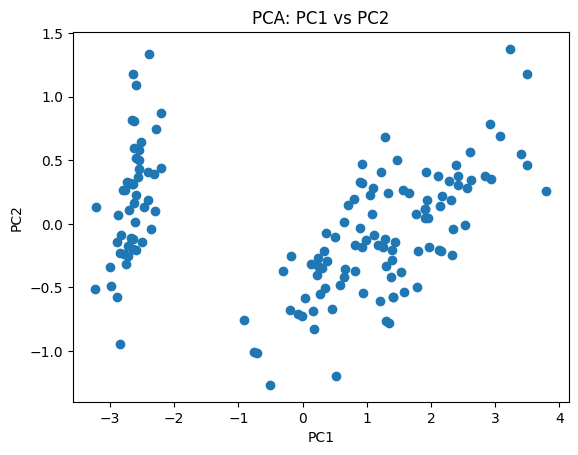

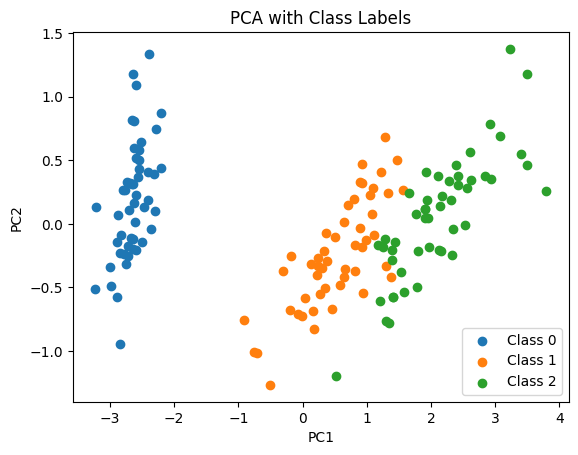

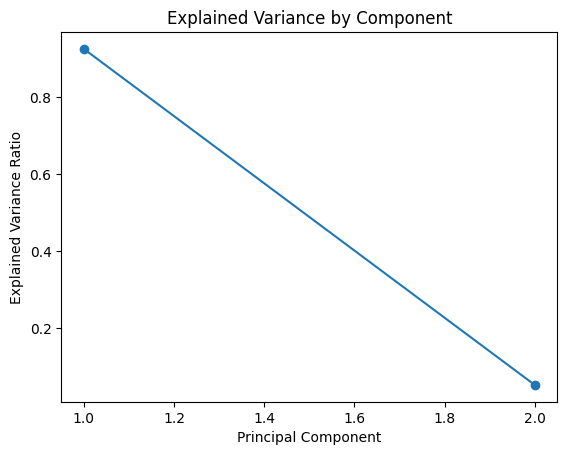

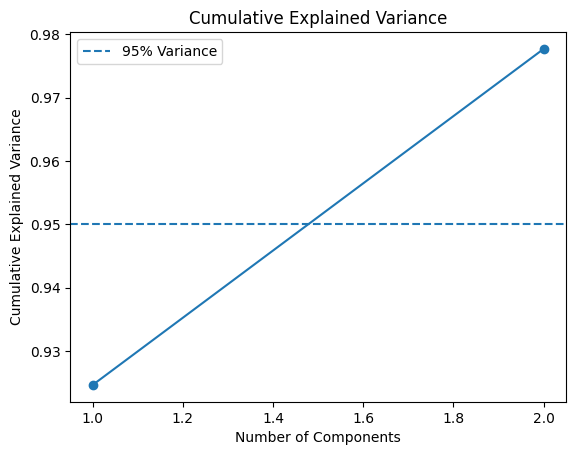

Principal Components:
[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]

Explained Variance:
[4.22824171 0.24267075]

Explained Variance Ratio:
[0.92461872 0.05306648]

Cumulative Explained Variance:
[0.92461872 0.97768521]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load a real dataset
iris = load_iris()

# X contains the original features
X = iris.data

# y contains the class labels
y = iris.target

# Create PCA
# Reduce the original 4 features to 2 principal components
pca = PCA(n_components=2)

# Fit PCA on the data and transform it
X_pca = pca.fit_transform(X)

# --------------------------------------------------
# PLOT 1: PC1 vs PC2
# --------------------------------------------------

# Create a new figure
plt.figure()

# Plot the observations using PC1 and PC2
# X_pca[:, 0] = PC1
# X_pca[:, 1] = PC2
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

# Label the axes
plt.xlabel("PC1")
plt.ylabel("PC2")

# Add a title
plt.title("PCA: PC1 vs PC2")

# Display the plot
plt.show()


# --------------------------------------------------
# PLOT 2: PC1 vs PC2 WITH CLASS LABELS
# --------------------------------------------------

# Create a new figure
plt.figure()

# Plot each class separately
plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    label="Class 1"
)

plt.scatter(
    X_pca[y == 2, 0],
    X_pca[y == 2, 1],
    label="Class 2"
)

# Label the axes
plt.xlabel("PC1")
plt.ylabel("PC2")

# Add a title
plt.title("PCA with Class Labels")

# Show the legend
plt.legend()

# Display the plot
plt.show()


# --------------------------------------------------
# PLOT 3: EXPLAINED VARIANCE OF EACH COMPONENT
# --------------------------------------------------

# Get the explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Create component numbers
components = range(1, len(explained_variance) + 1)

# Create a new figure
plt.figure()

# Plot explained variance for each component
plt.plot(
    components,
    explained_variance,
    marker="o"
)

# Label the axes
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

# Add a title
plt.title("Explained Variance by Component")

# Display the plot
plt.show()


# --------------------------------------------------
# PLOT 4: CUMULATIVE EXPLAINED VARIANCE
# --------------------------------------------------

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    explained_variance
)

# Create a new figure
plt.figure()

# Plot cumulative explained variance
plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

# Add a horizontal reference line at 95%
plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

# Label the axes
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

# Add a title
plt.title("Cumulative Explained Variance")

# Show the legend
plt.legend()

# Display the plot
plt.show()


# --------------------------------------------------
# PRINT THE PCA INFORMATION
# --------------------------------------------------

# Print the principal directions
print("Principal Components:")
print(pca.components_)

# Print the variance captured by each component
print("\nExplained Variance:")
print(pca.explained_variance_)

# Print the percentage of variance captured
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Print cumulative explained variance
print("\nCumulative Explained Variance:")
print(cumulative_variance)

# Topic 13: Evaluation and Interpretation

After applying PCA, we need to answer:

> **Did PCA actually reduce the dimensions while preserving the important structure of the data?**

PCA is not a supervised algorithm, so evaluation is different from classification algorithms where we might simply calculate accuracy.

We mainly look at:

1. Explained variance
2. Reconstruction error
3. Visualization
4. Performance of a downstream ML model

---

## 1. Explained Variance

The first thing we check is:

> How much variance did we preserve?

Suppose PCA gives:

$$
\text{Explained Variance Ratio}
=
\begin{bmatrix}
0.70\\
0.20\\
0.07\\
0.03
\end{bmatrix}
$$

This means:

$$
PC_1=70\%
$$

$$
PC_2=20\%
$$

$$
PC_3=7\%
$$

$$
PC_4=3\%
$$

If we keep PC1 and PC2:

$$
70\%+20\%
=
90\%
$$

So we reduced:

$$
4\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

while retaining 90% of the variance.

In Scikit-Learn:

```python
print(pca.explained_variance_ratio_)
```

---

# 2. Cumulative Explained Variance

We can calculate:

```python
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)
```

Suppose we get:

```text
[0.70, 0.90, 0.97, 1.00]
```

This means:

$$
PC_1
\rightarrow
70\%
$$

$$
PC_1+PC_2
\rightarrow
90\%
$$

$$
PC_1+PC_2+PC_3
\rightarrow
97\%
$$

Therefore, if our target is 90%, two components are enough.

---

# 3. Reconstruction Error

Explained variance tells us how much variance we kept.

Another question is:

> **How accurately can we reconstruct the original data after reducing it?**

Suppose the original data is:

$$
X
$$

We reduce it:

$$
X
\rightarrow
Z
$$

where \(Z\) is the reduced representation.

We can then approximately reconstruct the original data:

$$
Z
\rightarrow
\hat{X}
$$

Here:

$$
\hat{X}
=
\text{reconstructed data}
$$

The reconstruction will generally not be exactly equal to \(X\), because some components were discarded.

---

# 4. Why Does Reconstruction Error Matter?

Imagine:

$$
100\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

If we throw away too much information, the reconstructed data may be very different from the original.

But if:

$$
100\text{ dimensions}
\rightarrow
80\text{ dimensions}
$$

the reconstruction will usually be much closer.

So there is a trade-off:

$$
\text{Fewer Components}
\rightarrow
\text{More Compression}
\rightarrow
\text{More Reconstruction Error}
$$

while:

$$
\text{More Components}
\rightarrow
\text{Less Compression}
\rightarrow
\text{Less Reconstruction Error}
$$

---

# 5. Reconstruction with Scikit-Learn

Suppose:

```python
pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X)
```

Now reconstruct:

```python
X_reconstructed = pca.inverse_transform(X_reduced)
```

The flow is:

$$
X
\rightarrow
X_{\text{reduced}}
\rightarrow
X_{\text{reconstructed}}
$$

The reconstructed data is an approximation of the original data.

---

# 6. Measuring Reconstruction Error

A common measure is Mean Squared Error:

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\hat{x}_i)^2
$$

For multiple features, we can calculate the average squared difference across all values.

In Python:

```python
from sklearn.metrics import mean_squared_error

error = mean_squared_error(
    X,
    X_reconstructed
)

print("Reconstruction Error:", error)
```

A smaller value means the reconstruction is closer to the original data.

---

# 7. Small Example

Suppose one original feature contains:

$$
X=
\begin{bmatrix}
1\\
2\\
3
\end{bmatrix}
$$

After PCA and reconstruction, suppose we get:

$$
\hat{X}=
\begin{bmatrix}
1.1\\
1.9\\
3.0
\end{bmatrix}
$$

Calculate the squared errors.

For the first value:

$$
(1-1.1)^2
=
(-0.1)^2
=
0.01
$$

Second:

$$
(2-1.9)^2
=
(0.1)^2
=
0.01
$$

Third:

$$
(3-3.0)^2
=
0
$$

Therefore:

$$
\text{MSE}
=
\frac{0.01+0.01+0}{3}
$$

$$
=
\frac{0.02}{3}
$$

$$
\approx0.0067
$$

That's a small reconstruction error.

---

# 8. Visualization as Evaluation

We can also visualize the reduced data.

For example:

$$
X
\rightarrow
PC_1,PC_2
$$

and plot:

```python
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
```

We can visually inspect whether the important structure of the data is still visible.

For example, if the original data contains obvious groups and they remain reasonably visible after PCA, that's useful evidence that the chosen components retained meaningful structure.

However, visualization is only qualitative.

---

# 9. Evaluation Using a Downstream Model

Sometimes PCA is used before another machine-learning algorithm.

For example:

$$
X
\rightarrow
PCA
\rightarrow
X_{\text{reduced}}
\rightarrow
\text{Classifier}
$$

We can compare the model's performance:

### Without PCA

```text
Accuracy = 94%
```

### With PCA

```text
Accuracy = 93%
```

If PCA reduced:

$$
100\text{ features}
\rightarrow
20\text{ features}
$$

while accuracy only decreased from 94% to 93%, PCA may still be useful because we achieved a large dimensionality reduction.

---

# 10. But PCA Can Sometimes Improve Performance

Suppose the original data contains many redundant or noisy features.

Then:

$$
\text{Original Features}
\rightarrow
\text{Redundancy + Noise}
$$

PCA may compress the important variation into fewer components:

$$
\text{Original Features}
\rightarrow
\text{PCA}
\rightarrow
\text{Important Components}
$$

A downstream model might then perform better.

For example:

| Method        | Accuracy |
| ------------- | -------: |
| Original data |      88% |
| PCA           |      91% |

So PCA isn't necessarily only about compression.

It can sometimes act as a form of **noise reduction**.

---

# 11. Important Warning: PCA Is Unsupervised

Suppose you have:

$$
X=\text{features}
$$

and:

$$
y=\text{class labels}
$$

PCA does **not** look at \(y\).

It only sees \(X\).

Therefore, PCA chooses directions based on:

$$
\text{Maximum Variance}
$$

not:

$$
\text{Maximum Class Separation}
$$

This means a high-variance direction isn't necessarily the best direction for classification.

---

## Example

Suppose:

```text
PC1 → 90% variance
PC2 → 10% variance
```

You might assume PC1 is always the most useful.

But imagine that class information is mostly contained in PC2.

Then:

$$
PC_1
\rightarrow
90\%\text{ variance}
$$

but:

$$
PC_2
\rightarrow
\text{important class information}
$$

If you discard PC2, classification performance could suffer.

This is one reason we should not blindly say:

> "Always keep 95% variance."

We should also consider the actual task.

---

# 12. What Makes PCA Successful?

A good PCA reduction generally has:

### High explained variance

$$
\text{High variance preserved}
$$

### Low reconstruction error

$$
\text{Low reconstruction error}
$$

### Useful visualization

The important structure remains visible.

### Good downstream performance

If PCA is being used before another ML algorithm, its performance remains acceptable.

---

# 13. Complete Evaluation Flow

After PCA:

$$
X
\rightarrow
PCA
\rightarrow
X_{\text{reduced}}
$$

we can evaluate:

$$
X_{\text{reduced}}
\rightarrow
\text{Explained Variance}
$$

$$
X_{\text{reduced}}
\rightarrow
\text{Reconstruction}
\rightarrow
\text{Reconstruction Error}
$$

$$
X_{\text{reduced}}
\rightarrow
\text{Visualization}
$$

and, when appropriate:

$$
X_{\text{reduced}}
\rightarrow
\text{ML Model}
\rightarrow
\text{Performance}
$$

---

## The key idea

PCA evaluation is basically asking:

> **Did we remove dimensions without throwing away too much useful information?**

There isn't one single metric that answers this for every situation.

We combine:

$$
\boxed{
\text{Explained Variance}
+
\text{Reconstruction Error}
+
\text{Visualization}
+
\text{Downstream Performance}
}
$$


# Advantages, Limitations & Suitable Data Shapes


## 1. Advantages of PCA

### 1. Dimensionality Reduction

Reduces many features into fewer components:

$$
100\text{ features}
\rightarrow
10\text{ principal components}
$$

while retaining much of the variance.

### 2. Removes Redundancy

If multiple features contain similar information, PCA can combine them into fewer components.

$$
\text{Correlated Features}
\rightarrow
\text{Fewer Components}
$$

### 3. Visualization

High-dimensional data can be reduced to 2D or 3D:

$$
50\text{ dimensions}
\rightarrow
2\text{ dimensions}
$$

making visualization possible.

### 4. Can Reduce Noise

Low-variance components may contain relatively little useful variation, so removing them can sometimes reduce noise.

### 5. Faster ML Models

Fewer features can reduce computation and memory requirements for downstream models.

---

# 2. Limitations of PCA

### 1. PCA Is Linear

PCA mainly finds **linear directions**.

If the important structure is nonlinear, PCA may fail to capture it well.

### 2. Sensitive to Feature Scale

If features have very different scales, a large-scale feature can dominate PCA.

For example:

$$
\text{Income}\sim100000
$$

while:

$$
\text{Age}\sim20
$$

Scaling may be necessary before PCA.

### 3. Components Can Be Difficult to Interpret

Original features might have clear meanings:

$$
\text{Age},\text{Income},\text{Height}
$$

but a component may be a combination:

$$
PC_1=
\begin{bmatrix}
0.52\\
0.71\\
0.46
\end{bmatrix}
$$

So interpreting what PC1 actually means can be difficult.

### 4. PCA Maximizes Variance, Not Class Separation

PCA does not use labels.

$$
\boxed{
\text{Maximum Variance}
\neq
\text{Maximum Classification Separation}
}
$$

A low-variance direction can sometimes contain important predictive information.

### 5. Some Information Is Lost

When components are discarded:

$$
\text{Original Dimensions}
\rightarrow
\text{Fewer Dimensions}
$$

some variance is inevitably removed.

---

# 3. Suitable Data Shapes

PCA works with a data matrix:

$$
X\in\mathbb{R}^{n\times d}
$$

where:

* \(n\) = number of observations/samples
* \(d\) = number of features

For example:

$$
X=
\begin{bmatrix}
x_{11}&x_{12}&x_{13}\\
x_{21}&x_{22}&x_{23}\\
x_{31}&x_{32}&x_{33}\\
x_{41}&x_{42}&x_{43}
\end{bmatrix}
$$

Here:

$$
n=4
$$

and:

$$
d=3
$$

So we have **4 samples and 3 features**.

---

## When PCA Is Particularly Useful

PCA is useful when:

* There are **many numerical features**
* Features are correlated
* There is redundancy
* You want dimensionality reduction
* You want to visualize high-dimensional data
* You want to reduce computational complexity

For example:

$$
1000\text{ features}
\rightarrow
50\text{ components}
$$

---

## When PCA May Not Be the Best Choice

Be careful when:

* The data has important nonlinear structure
* Interpretability of original features is critical
* Features are categorical rather than numerical
* Class separation is more important than variance preservation

For nonlinear dimensionality reduction, methods such as **t-SNE** and **UMAP** can be more appropriate.

---

## Final PCA Mental Model

$$
\text{Data}
\rightarrow
\text{Center}
\rightarrow
\text{Covariance}
\rightarrow
\text{Eigenvectors}
\rightarrow
\text{Principal Components}
\rightarrow
\text{Select}
\rightarrow
\text{Reduce}
$$

**PCA is best thought of as:** finding a new set of directions that capture the maximum variance, then keeping only the most important directions.
